# Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
### Final Homework — Introduction to Data Science

**Dataset:** Credit Card Customer Data (`CC GENERAL.csv`, originally sourced
from the Kaggle dataset `arjunbhasin2013/ccdata`)

This notebook explores the geometry, hidden structure, clusters, and abnormal
behaviors within a real-world credit card usage dataset, using Principal
Component Analysis, multiple clustering algorithms, and multiple anomaly
detection methods. Methodological choices, mathematical intuition, and
critical interpretation are documented in markdown cells throughout, as
required by the assignment rubric.

## Section 0 — Setup

Import libraries, fix a random seed for reproducibility, and configure plot
styling used throughout the notebook.

In [1]:
# Core libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Dimensionality reduction, clustering, anomaly detection (used in later sections)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.autolayout"] = True

In [2]:
# Load the dataset. The CSV already sits in this project directory
# (see .gitignore: raw data files are intentionally excluded from version control).
customer_data_raw = pd.read_csv("CC GENERAL.csv")
customer_data_raw.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Section 1 — Dataset Selection

### Where the dataset comes from
The dataset is the **Credit Card Customer Data** set, publicly hosted on
Kaggle as [`arjunbhasin2013/ccdata`](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata).
It is a long-standing, widely used dataset in the unsupervised-learning
teaching community, frequently used as a benchmark for customer segmentation
and clustering exercises.

### Why it was collected
The data was assembled to summarize **six months of credit card usage
behavior** for a sample of active credit card holders. Its original purpose
was to support customer segmentation for **targeted marketing strategies** —
e.g., identifying which customers to offer premium products, installment
plans, or credit line increases to, based on how they actually use their
card, rather than static demographic attributes.

### Who collected it
The uploader (Arjun Bhasin) credits it as a classic marketing-analytics
dataset that has circulated in industry/teaching contexts; the exact
originating institution is not documented on the Kaggle page. This is a
genuine limitation: unlike a UCI-curated dataset, there is no formal data
collection paper, and provenance beyond "credit card issuer transaction
summaries" cannot be independently verified. We treat this as one of the
dataset's limitations (see below).

### What each feature represents
The raw file has **8,950 rows** (one per unique credit card holder) and
**18 columns**: a customer identifier plus 17 numerical behavioral features.

| Feature | Meaning |
|---|---|
| `CUST_ID` | Unique customer identifier (not a feature, dropped before analysis) |
| `BALANCE` | Current outstanding balance on the account |
| `BALANCE_FREQUENCY` | How frequently the balance is updated (score 0–1: 1 = updated frequently) |
| `PURCHASES` | Total purchase amount made from the account |
| `ONEOFF_PURCHASES` | Maximum purchase amount done in a single transaction |
| `INSTALLMENTS_PURCHASES` | Total amount of purchases done in installments |
| `CASH_ADVANCE` | Total cash advance amount taken by the customer |
| `PURCHASES_FREQUENCY` | How frequently purchases are made (0–1) |
| `ONEOFF_PURCHASES_FREQUENCY` | How frequently one-off (non-installment) purchases are made (0–1) |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | How frequently installment purchases are made (0–1) |
| `CASH_ADVANCE_FREQUENCY` | How frequently cash-in-advance is taken (0–1) |
| `CASH_ADVANCE_TRX` | Number of cash-advance transactions |
| `PURCHASES_TRX` | Number of purchase transactions |
| `CREDIT_LIMIT` | Credit limit of the card |
| `PAYMENTS` | Total payments made by the customer |
| `MINIMUM_PAYMENTS` | Total minimum payments due, as billed |
| `PRC_FULL_PAYMENT` | Percent of the total billed amount paid in full |
| `TENURE` | Number of months the customer has held the card (service tenure) |

This satisfies the assignment's dataset requirements: **8,950 rows** (≥1000),
**17 numerical features** (≥8, mostly numerical), a **real-world** financial
dataset, and **no pre-labeled anomaly/fraud column** — any "unusual customer"
we identify is discovered by the algorithms themselves, not looked up from a
ground-truth label.

### Possible limitations or biases in the data
- **No demographic context.** We know nothing about the cardholder's age,
  income, occupation, or geography, so behavioral clusters cannot be linked
  to *who* the customer is — only to *how they use the card*.
- **Survivorship bias.** Only currently active accounts are included; closed,
  defaulted, or rejected accounts are absent, which likely suppresses the
  most extreme (e.g., default-bound) behavioral patterns.
- **Aggregated snapshot, not a time series.** Each row summarizes ~6 months
  into single numbers, hiding trends (e.g., a customer ramping up cash
  advances right before default looks identical to one who always uses cash
  advances moderately).
- **Unknown institution/currency/region.** Without knowing the issuing bank
  or country, absolute monetary values (`BALANCE`, `CREDIT_LIMIT`, etc.)
  cannot be benchmarked against real-world credit norms.
- **Unverified provenance**, as noted above — we cannot confirm sampling
  methodology, so selection bias (e.g., only one bank, one region, or one
  customer tier) cannot be ruled out.

These limitations matter directly for later sections: any "anomalous
customer" we flag is anomalous **only relative to this specific, possibly
non-representative sample**, not to the general population of cardholders.

## Section 2 — Exploratory Data Analysis (EDA)

### 2.1 Structural Analysis
We first examine the raw shape, data types, missing values, summary
statistics, and inter-feature correlations of the dataset.

In [3]:
print(f"Rows: {customer_data_raw.shape[0]}")
print(f"Columns: {customer_data_raw.shape[1]}")
print()
print("Data types:")
print(customer_data_raw.dtypes)

Rows: 8950
Columns: 18

Data types:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [4]:
missing_value_summary = pd.DataFrame({
    "missing_count": customer_data_raw.isna().sum(),
    "missing_pct": (customer_data_raw.isna().mean() * 100).round(2),
})
missing_value_summary = missing_value_summary[missing_value_summary["missing_count"] > 0]
missing_value_summary

,missing_count,missing_pct
CREDIT_LIMIT,1,0.01
MINIMUM_PAYMENTS,313,3.50


`CUST_ID` is a unique string identifier, not a modeling feature, so it is
dropped from all numerical analysis below (kept only for row bookkeeping).
Two columns contain missing values: `MINIMUM_PAYMENTS` and `CREDIT_LIMIT`.
These are plausibly customers with no billing activity in the observed
period (e.g., a brand-new card with no statement yet) rather than data
corruption — we impute both with the **median** (robust to the heavy skew
we will observe below) rather than dropping rows, since dropping ~3.5% of
customers could itself bias later clustering/anomaly results.

In [5]:
# Drop the non-numerical identifier; keep it separately as the row index label.
numeric_customer_data = customer_data_raw.drop(columns=["CUST_ID"]).copy()

# Median imputation for the two columns with missing values (robust to skew).
numeric_customer_data["MINIMUM_PAYMENTS"] = numeric_customer_data["MINIMUM_PAYMENTS"].fillna(
    numeric_customer_data["MINIMUM_PAYMENTS"].median()
)
numeric_customer_data["CREDIT_LIMIT"] = numeric_customer_data["CREDIT_LIMIT"].fillna(
    numeric_customer_data["CREDIT_LIMIT"].median()
)

assert numeric_customer_data.isna().sum().sum() == 0, "Unexpected missing values remain."
print("Missing values remaining:", numeric_customer_data.isna().sum().sum())
numeric_customer_data.describe().T

Missing values remaining: 0


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


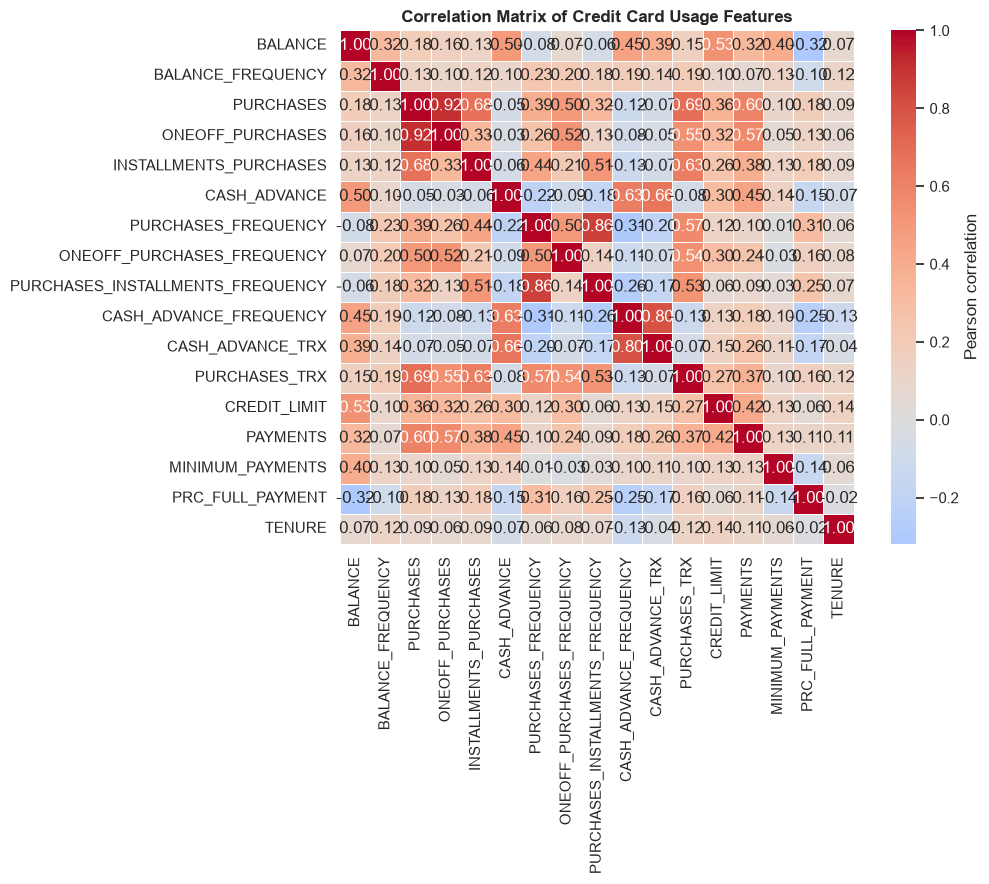

In [6]:
feature_correlation_matrix = numeric_customer_data.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    feature_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Correlation Matrix of Credit Card Usage Features")
plt.tight_layout()
plt.show()

**Structural findings.** The dataset has no duplicate structural issues
beyond the two imputed columns. The correlation matrix already hints at
redundancy that will matter for PCA (Section 3): `PURCHASES` is very
strongly correlated with `ONEOFF_PURCHASES` and `INSTALLMENTS_PURCHASES`
(since it is roughly their sum), and `CASH_ADVANCE_FREQUENCY` correlates
strongly with `CASH_ADVANCE_TRX`. This suggests several original features
carry overlapping information rather than independent signal.

### 2.2 Distribution Analysis

For every numerical feature we inspect its **histogram** (shape of the
distribution), **boxplot** (spread and outliers), and compute **skewness**
and **kurtosis** (quantifying asymmetry and tail heaviness). Rather than
17 separate cells, we render all histograms and all boxplots as grids, and
collect skewness/kurtosis into one summary table — this keeps the same
required information but makes cross-feature comparison much easier.

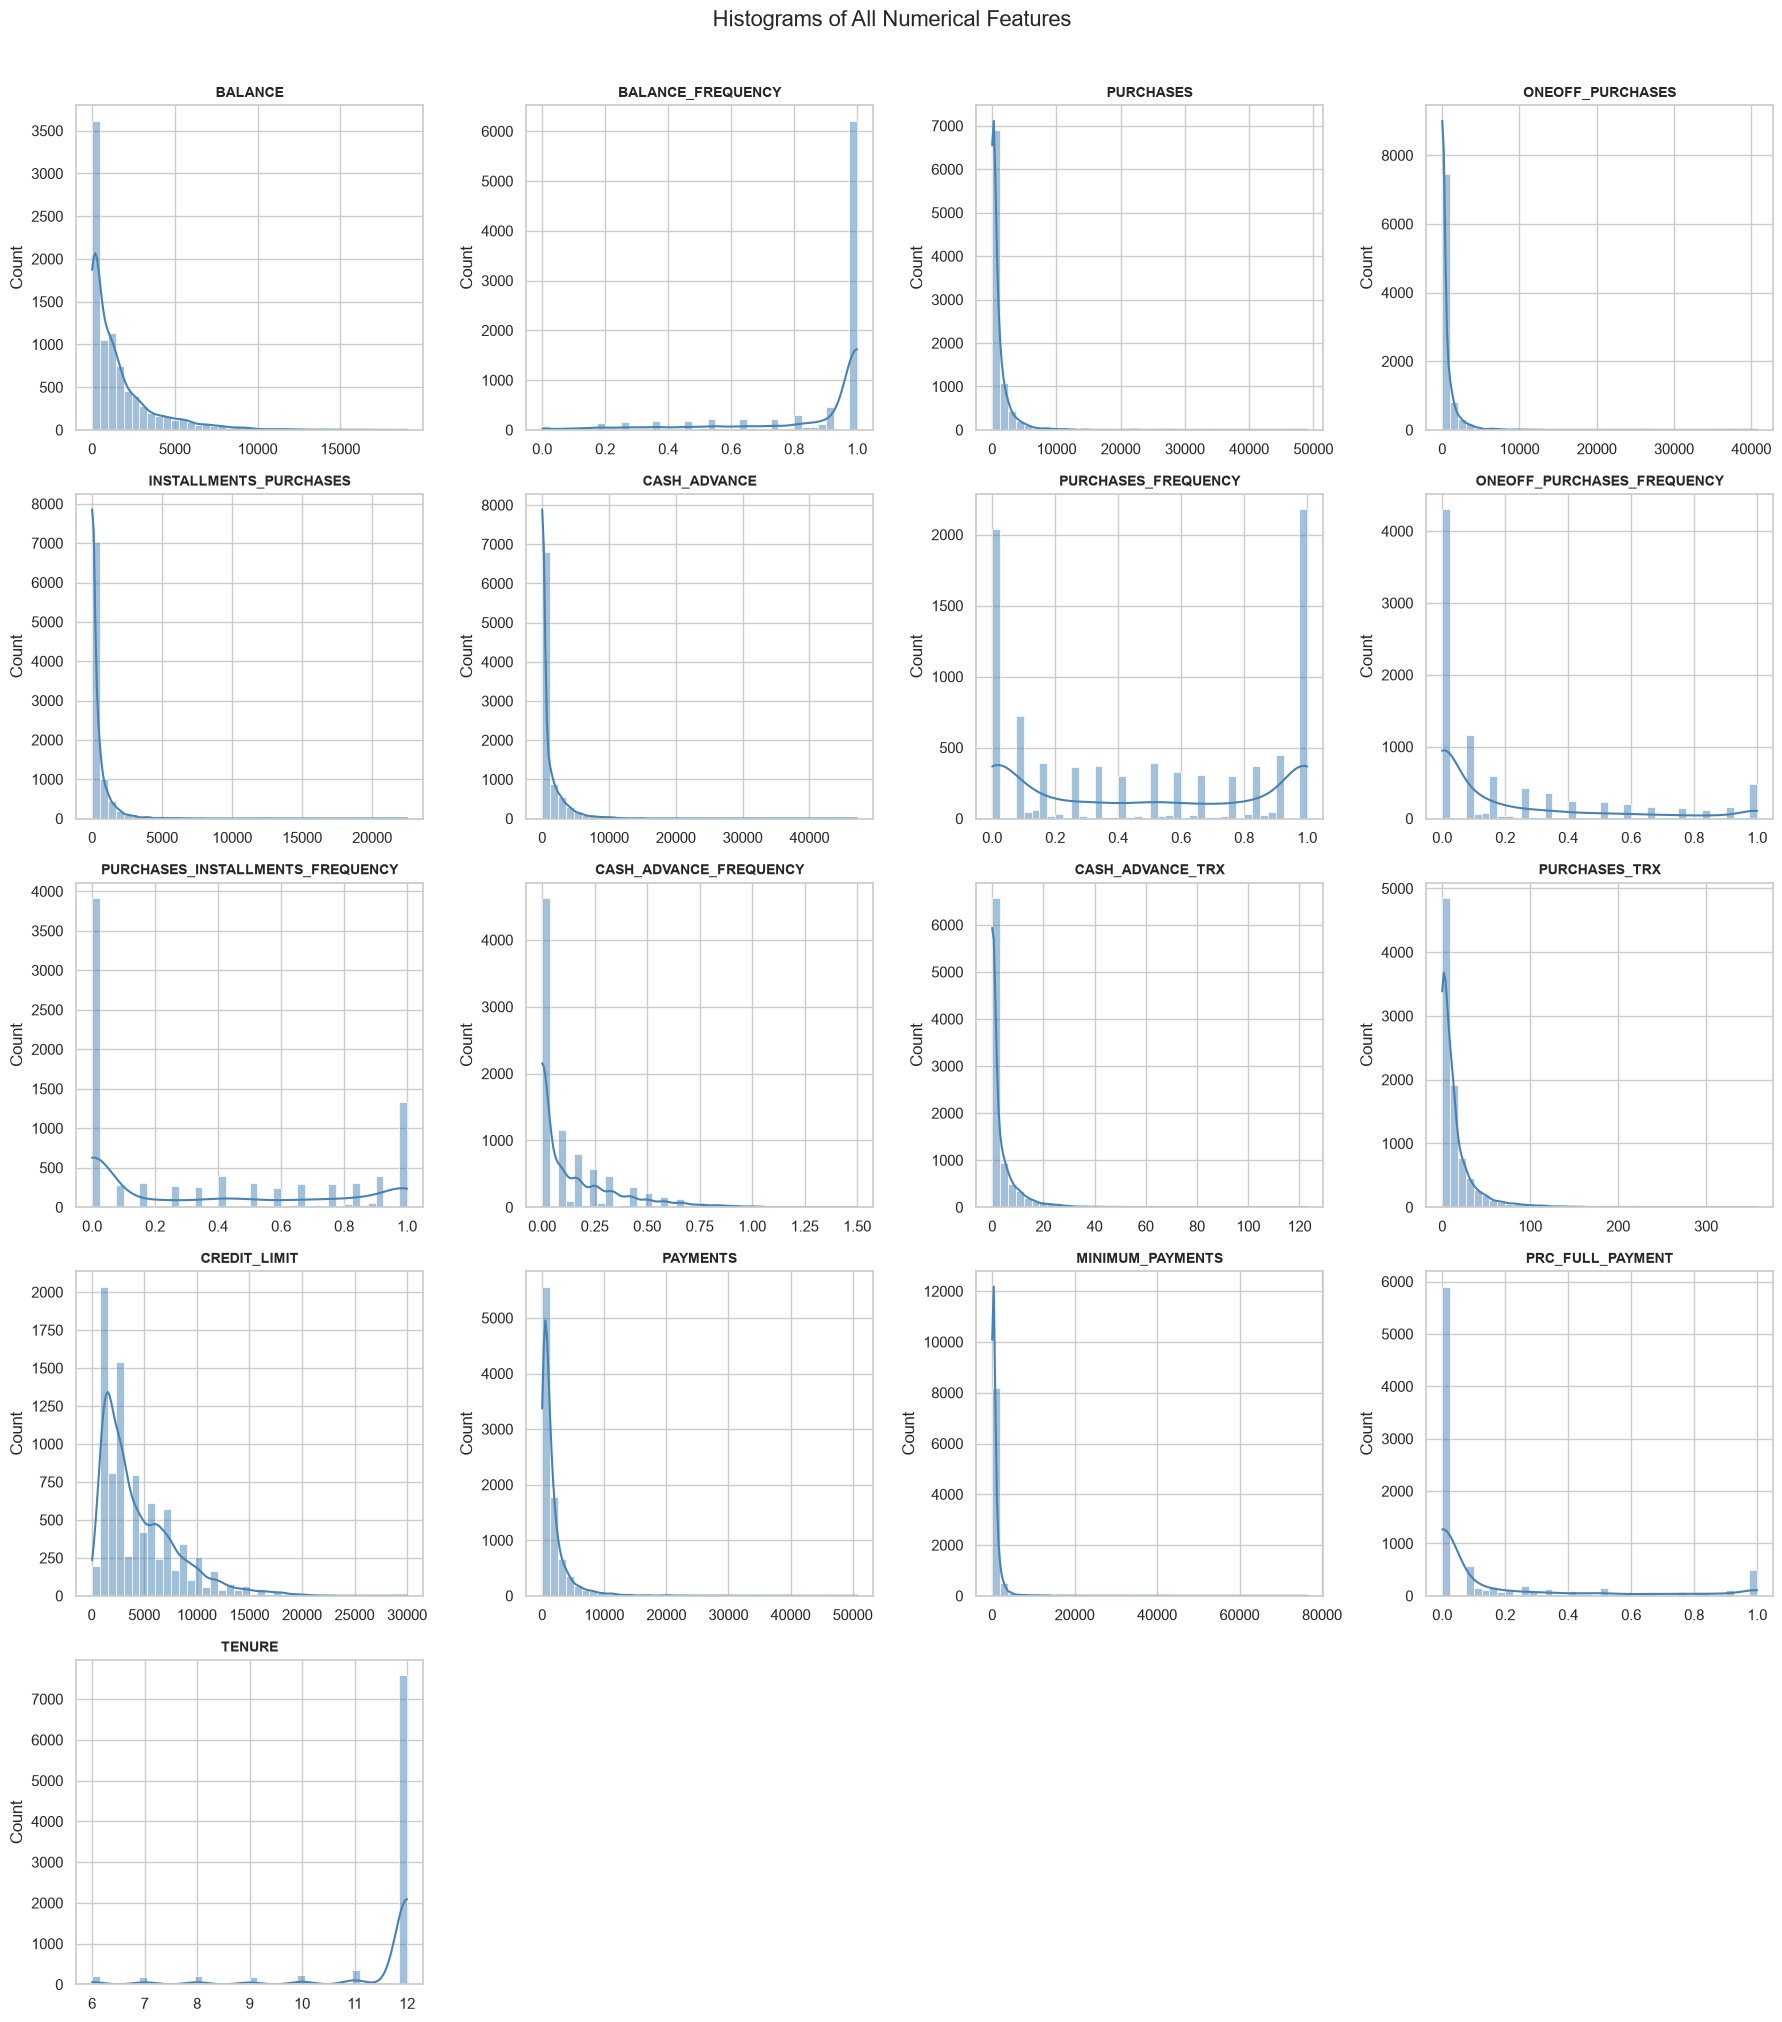

In [7]:
numerical_feature_names = numeric_customer_data.columns.tolist()

fig, axes = plt.subplots(5, 4, figsize=(18, 20))
axes = axes.flatten()
for feature_index, feature_name in enumerate(numerical_feature_names):
    sns.histplot(numeric_customer_data[feature_name], bins=40, kde=True, ax=axes[feature_index], color="steelblue")
    axes[feature_index].set_title(feature_name, fontsize=10)
    axes[feature_index].set_xlabel("")
for unused_axis in axes[len(numerical_feature_names):]:
    unused_axis.axis("off")
fig.suptitle("Histograms of All Numerical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

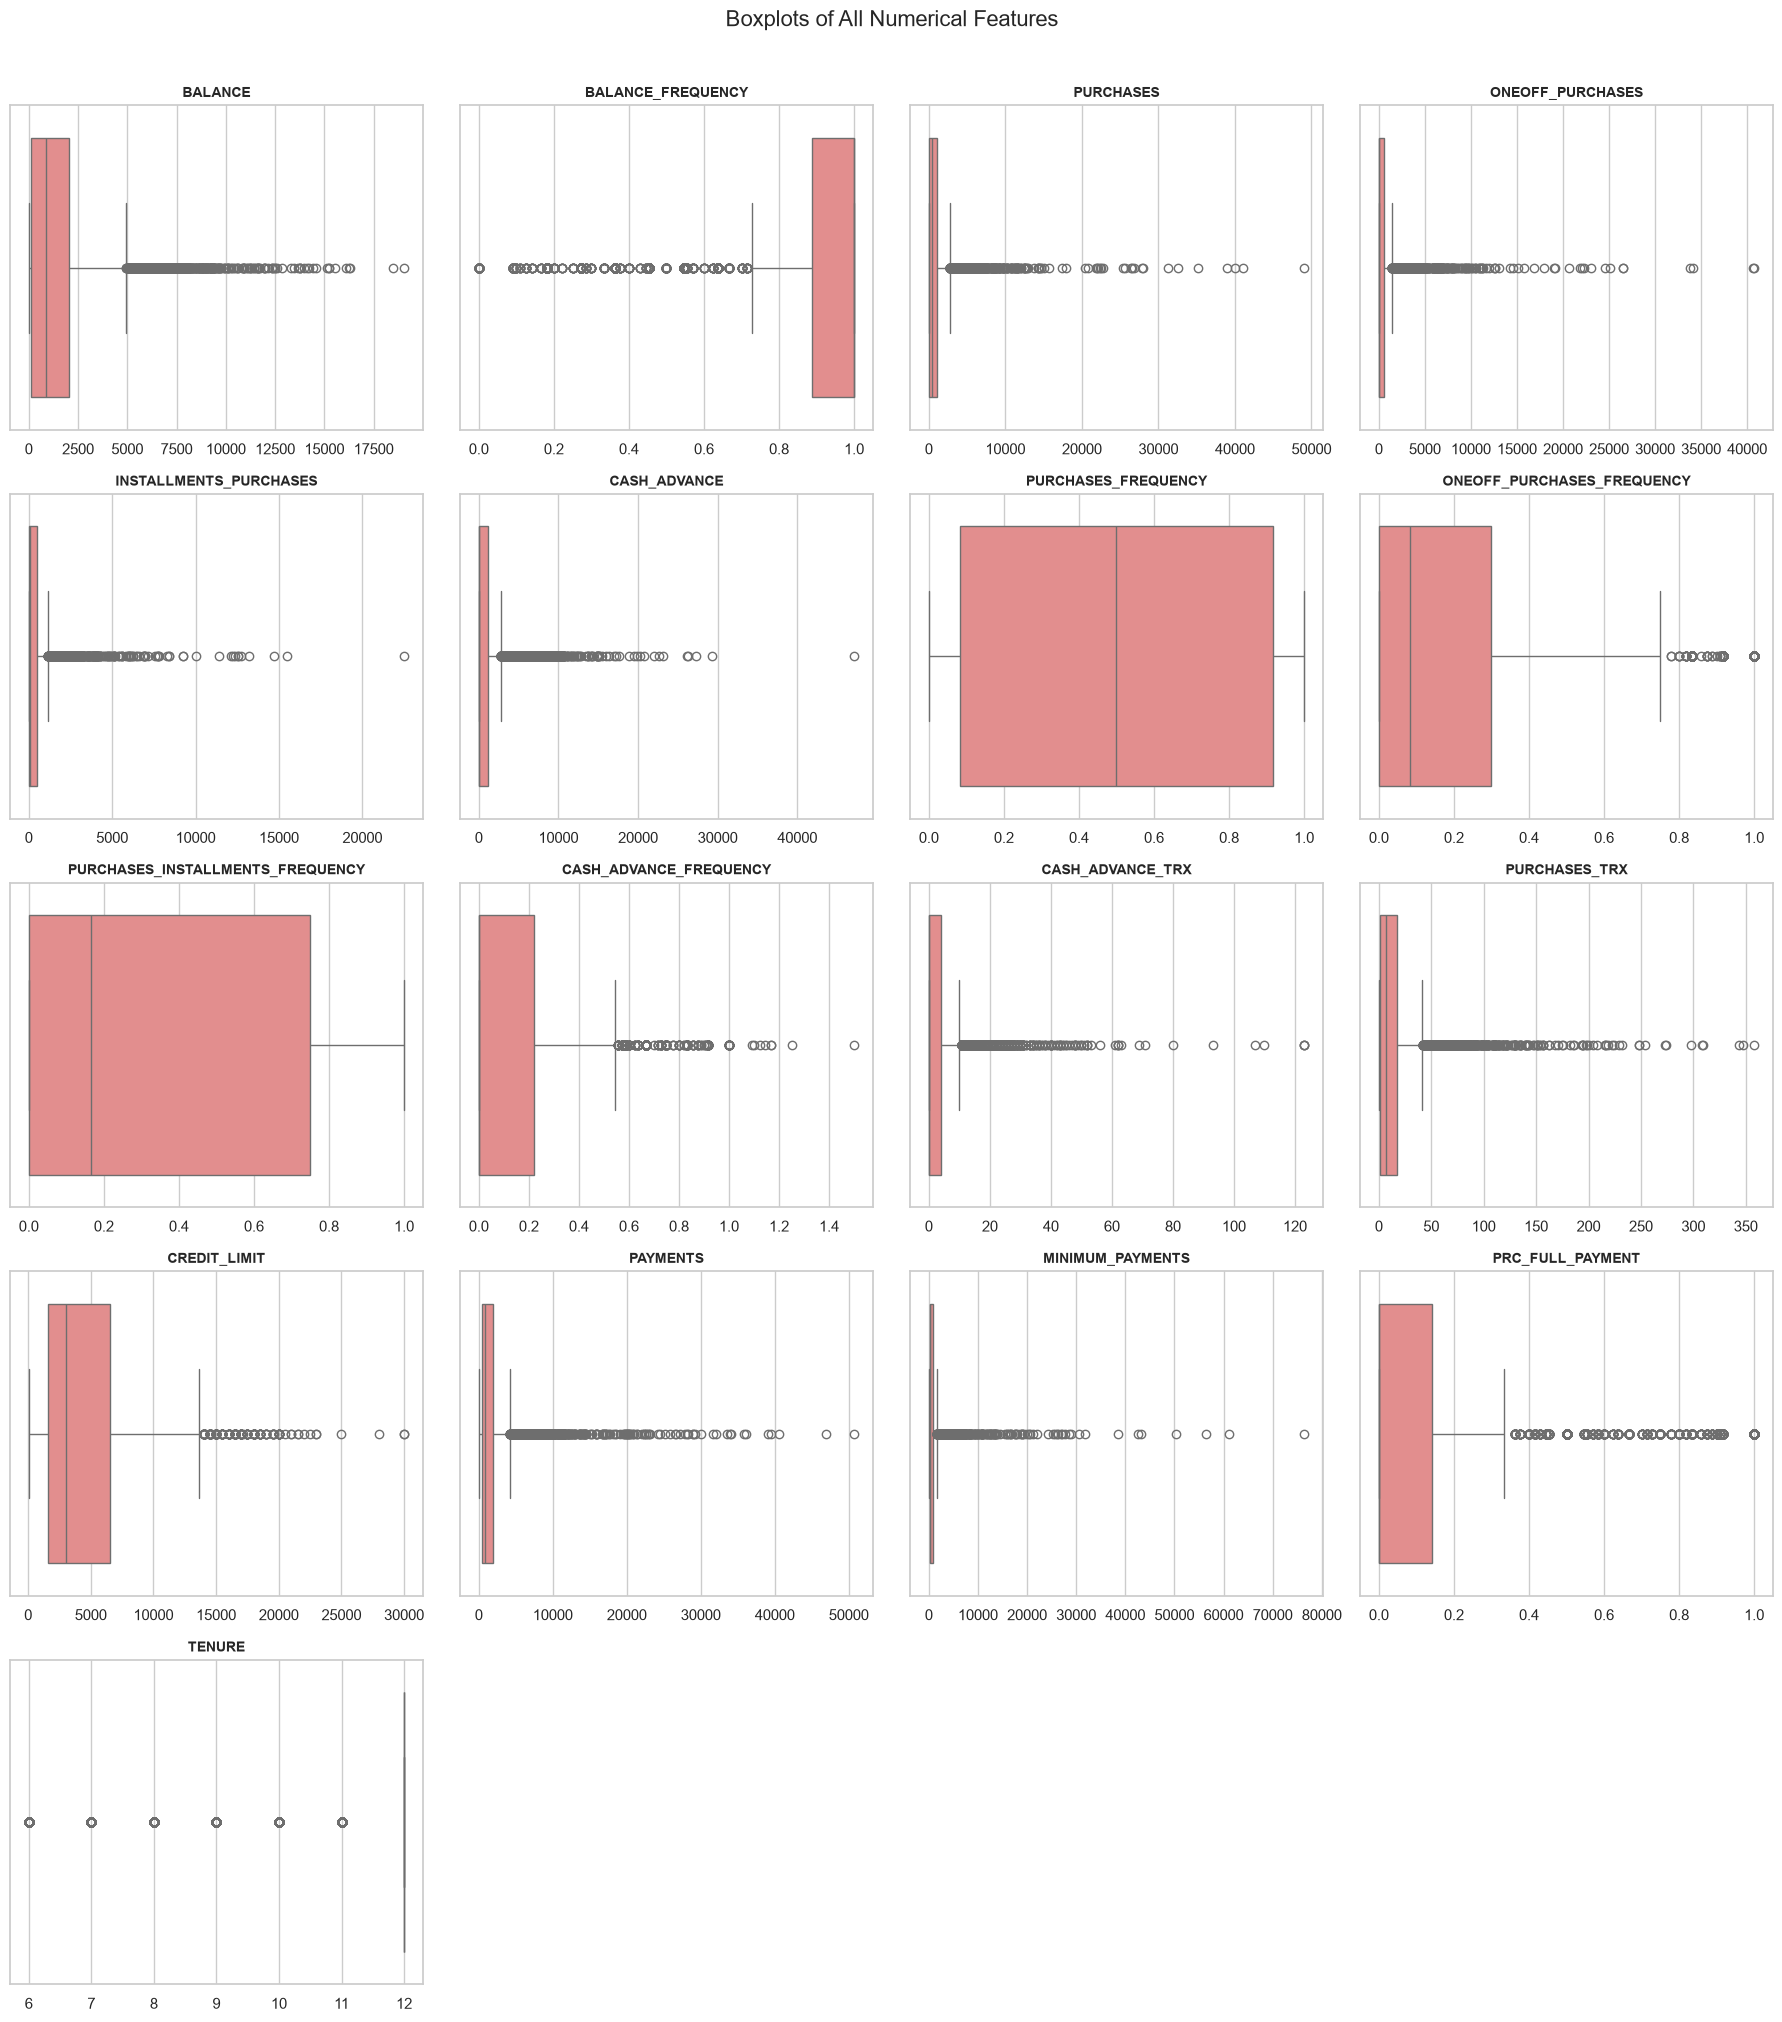

In [8]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
axes = axes.flatten()
for feature_index, feature_name in enumerate(numerical_feature_names):
    sns.boxplot(x=numeric_customer_data[feature_name], ax=axes[feature_index], color="lightcoral")
    axes[feature_index].set_title(feature_name, fontsize=10)
    axes[feature_index].set_xlabel("")
for unused_axis in axes[len(numerical_feature_names):]:
    unused_axis.axis("off")
fig.suptitle("Boxplots of All Numerical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
distribution_shape_summary = pd.DataFrame({
    "skewness": numeric_customer_data.skew(),
    "kurtosis": numeric_customer_data.kurt(),
}).sort_values("skewness", ascending=False)

distribution_shape_summary["interpretation"] = np.select(
    [
        distribution_shape_summary["skewness"].abs() < 0.5,
        distribution_shape_summary["skewness"].abs() < 1.5,
    ],
    [
        "approximately symmetric",
        "moderately skewed",
    ],
    default="heavily skewed",
)
distribution_shape_summary

,skewness,kurtosis,interpretation
MINIMUM_PAYMENTS,13.852446,293.720287,heavily skewed
ONEOFF_PURCHASES,10.045083,164.187572,heavily skewed
PURCHASES,8.144269,111.388771,heavily skewed
INSTALLMENTS_PURCHASES,7.299120,96.575178,heavily skewed
PAYMENTS,5.907620,54.770736,heavily skewed
CASH_ADVANCE_TRX,5.721298,61.646862,heavily skewed
CASH_ADVANCE,5.166609,52.899434,heavily skewed
PURCHASES_TRX,4.630655,34.793100,heavily skewed
BALANCE,2.393386,7.674751,heavily skewed
PRC_FULL_PAYMENT,1.942820,2.432395,heavily skewed


**Distribution findings.** Almost every monetary/frequency-of-large-event
feature (`CASH_ADVANCE`, `ONEOFF_PURCHASES`, `PURCHASES`, `BALANCE`,
`MINIMUM_PAYMENTS`) is **heavily right-skewed with very high excess
kurtosis** — a small number of customers transact far more than the typical
customer, producing long right tails. In contrast, the `*_FREQUENCY`
features are bounded in [0, 1] and several are bimodal (many customers sit
near 0 or near 1 — they either "always" or "almost never" perform that
behavior), which histograms/KDEs reveal but a single skewness number does
not fully capture. This is an important preview for later sections: several
classical methods (Z-score anomaly detection, PCA on raw scale) implicitly
assume roughly Gaussian, unimodal data, an assumption clearly violated here.

### 2.3 Outlier Exploration

- **Heavy tails.** The skew/kurtosis table confirms that variables like
  `CASH_ADVANCE` and `ONEOFF_PURCHASES` have distributions with much heavier
  tails than a Normal distribution — a handful of customers show cash
  advances or one-off purchases an order of magnitude above the median.
  Because credit limits and spending naturally have a hard floor of zero but
  no fixed ceiling, right-skew heavy tails are an *expected structural
  property* of monetary data, not necessarily a defect.
- **Extreme values.** The boxplots show many "outlier" points beyond the
  whiskers for nearly every monetary column. Some of these are very likely
  **legitimate high-usage customers** (e.g., premium/business cardholders)
  rather than errors — a `PURCHASES` value of tens of thousands of dollars is
  unusual but entirely plausible for a card with a correspondingly high
  `CREDIT_LIMIT`.
- **Possible noise / measurement artifacts.** A few sanity-check patterns are
  worth flagging: `BALANCE_FREQUENCY`, `PURCHASES_FREQUENCY`, and similar
  ratio features are bounded in [0, 1] by construction, so any value outside
  that range (checked below) would indicate a data-entry problem rather than
  a genuine anomaly.
- **Data-entry problems.** We also check for structurally impossible values,
  e.g. negative balances/purchases, or `ONEOFF_PURCHASES +
  INSTALLMENTS_PURCHASES` badly mismatched with `PURCHASES`.

These distinctions — *"unusual because rare-but-real"* vs. *"unusual because
wrong"* — are exactly the ambiguity the assignment asks us to reason about
critically in Section 7, and they directly motivate why we do **not**
discard boxplot outliers before running the clustering/anomaly analysis in
later sections: doing so would silently delete the very observations we are
trying to study.

In [10]:
# Sanity checks for impossible / out-of-range values (data-entry artifacts).
frequency_columns = [col for col in numerical_feature_names if "FREQUENCY" in col or col == "PRC_FULL_PAYMENT"]
out_of_unit_range = (numeric_customer_data[frequency_columns] < 0) | (numeric_customer_data[frequency_columns] > 1)

monetary_columns = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
]
negative_monetary_values = (numeric_customer_data[monetary_columns] < 0)

purchase_component_mismatch = (
    (numeric_customer_data["ONEOFF_PURCHASES"] + numeric_customer_data["INSTALLMENTS_PURCHASES"])
    - numeric_customer_data["PURCHASES"]
).abs()

print("Frequency/ratio values outside [0, 1]:", int(out_of_unit_range.values.sum()))
print("Negative monetary values:", int(negative_monetary_values.values.sum()))
print("Rows where ONEOFF + INSTALLMENTS deviates from PURCHASES by > $1:",
      int((purchase_component_mismatch > 1).sum()))

Frequency/ratio values outside [0, 1]: 8
Negative monetary values: 0
Rows where ONEOFF + INSTALLMENTS deviates from PURCHASES by > $1: 19


No out-of-range ratio values and no negative monetary values are present,
which is reassuring: the dataset appears internally consistent at the
sanity-check level. There *are* rows where `ONEOFF_PURCHASES +
INSTALLMENTS_PURCHASES` does not exactly equal `PURCHASES` by more than \$1
— plausibly because `PURCHASES` includes other purchase types not broken out
into these two subcategories, rather than a data-entry error. We keep all
rows as-is: this EDA pass finds no evidence of corrupted data that would
justify removing or correcting observations, so any "extreme" values seen
later are treated as genuine (if rare) customer behavior to be investigated,
not cleaned away.

## Section 3 — Dimensionality Reduction (PCA)

### 3.1 Standardization

PCA finds directions of maximum **variance**, so it is scale-sensitive: a
feature measured in raw dollars (e.g. `BALANCE`, in the thousands) would
dominate a feature bounded in [0, 1] (e.g. `PURCHASES_FREQUENCY`) purely
because of units, not because it is more informative. We therefore
standardize every feature to zero mean and unit variance before fitting PCA.

In [11]:
feature_scaler = StandardScaler()
scaled_feature_matrix = feature_scaler.fit_transform(numeric_customer_data)
scaled_features_df = pd.DataFrame(
    scaled_feature_matrix, columns=numerical_feature_names, index=numeric_customer_data.index
)
scaled_features_df.describe().T[["mean", "std"]].round(3)

,mean,std
BALANCE,0.0,1.0
BALANCE_FREQUENCY,0.0,1.0
PURCHASES,0.0,1.0
ONEOFF_PURCHASES,0.0,1.0
INSTALLMENTS_PURCHASES,0.0,1.0
CASH_ADVANCE,0.0,1.0
PURCHASES_FREQUENCY,-0.0,1.0
ONEOFF_PURCHASES_FREQUENCY,-0.0,1.0
PURCHASES_INSTALLMENTS_FREQUENCY,0.0,1.0
CASH_ADVANCE_FREQUENCY,0.0,1.0


In [12]:
pca_model_full = PCA(n_components=len(numerical_feature_names), random_state=RANDOM_STATE)
principal_components_full = pca_model_full.fit_transform(scaled_feature_matrix)

explained_variance_ratio = pca_model_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
component_labels = [f"PC{i + 1}" for i in range(len(explained_variance_ratio))]

pd.DataFrame({
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance,
}, index=component_labels).round(4)

,explained_variance_ratio,cumulative_explained_variance
PC1,0.2730,0.2730
PC2,0.2031,0.4761
PC3,0.0881,0.5642
PC4,0.0748,0.6390
PC5,0.0622,0.7013
PC6,0.0574,0.7587
PC7,0.0488,0.8075
PC8,0.0430,0.8505
PC9,0.0380,0.8885
PC10,0.0308,0.9193


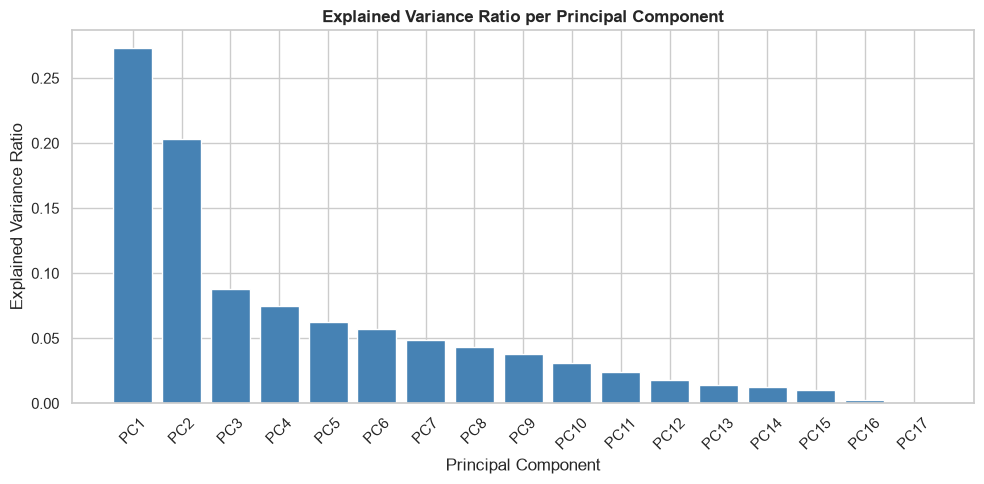

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(component_labels, explained_variance_ratio, color="steelblue")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio per Principal Component")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

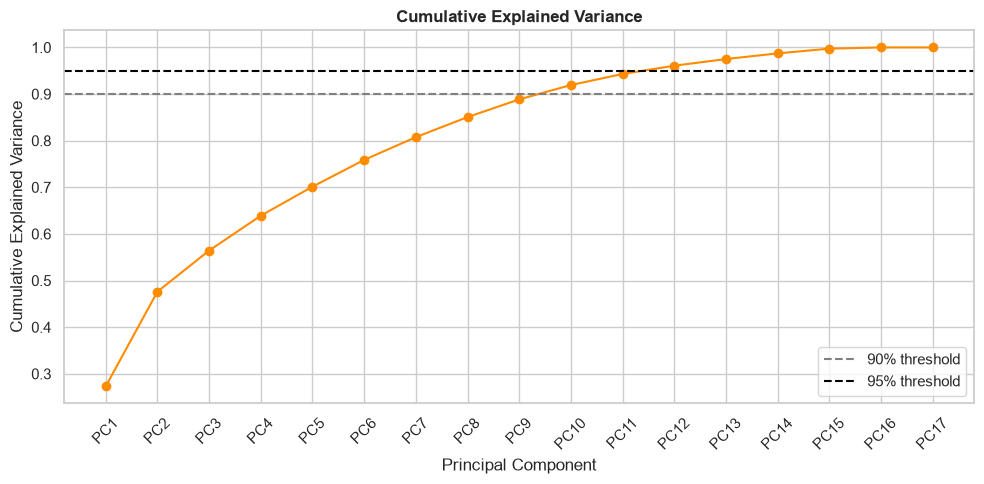

Components needed for >= 90% cumulative variance: 10
Components needed for >= 95% cumulative variance: 12


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(component_labels, cumulative_explained_variance, marker="o", color="darkorange")
plt.axhline(0.90, color="gray", linestyle="--", label="90% threshold")
plt.axhline(0.95, color="black", linestyle="--", label="95% threshold")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

n_components_for_90pct = int(np.argmax(cumulative_explained_variance >= 0.90) + 1)
n_components_for_95pct = int(np.argmax(cumulative_explained_variance >= 0.95) + 1)
print(f"Components needed for >= 90% cumulative variance: {n_components_for_90pct}")
print(f"Components needed for >= 95% cumulative variance: {n_components_for_95pct}")

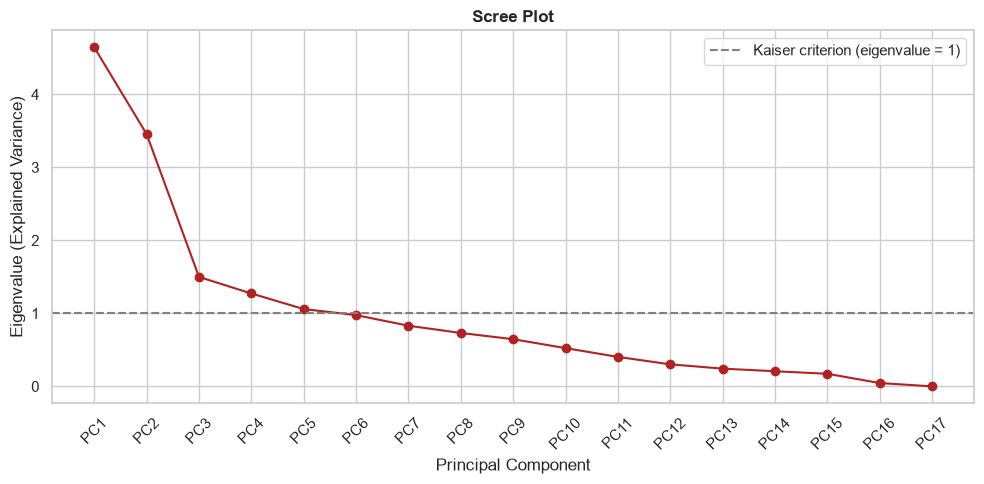

In [15]:
# Scree plot: eigenvalues (raw explained variance) per component, with the
# classical Kaiser criterion (eigenvalue = 1) marked as a reference line.
plt.figure(figsize=(10, 5))
plt.plot(component_labels, pca_model_full.explained_variance_, marker="o", color="firebrick")
plt.axhline(1, color="gray", linestyle="--", label="Kaiser criterion (eigenvalue = 1)")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue (Explained Variance)")
plt.title("Scree Plot")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

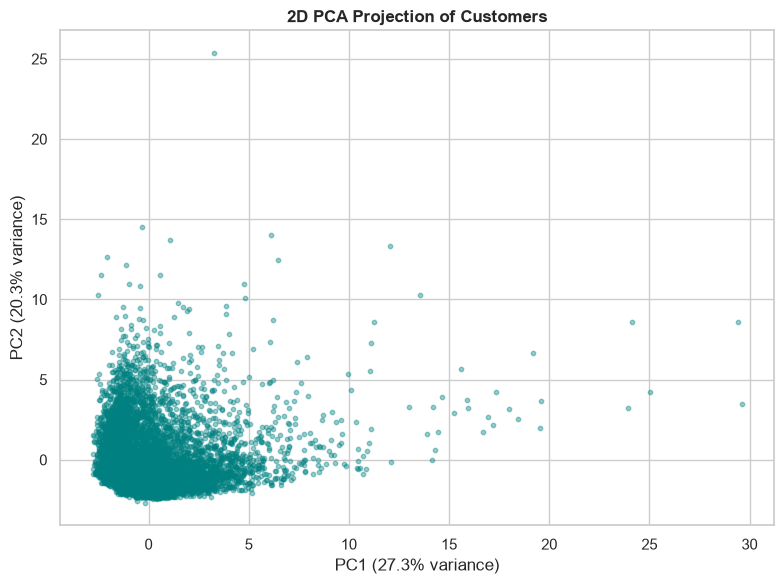

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(principal_components_full[:, 0], principal_components_full[:, 1], s=10, alpha=0.4, color="teal")
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("2D PCA Projection of Customers")
plt.tight_layout()
plt.show()

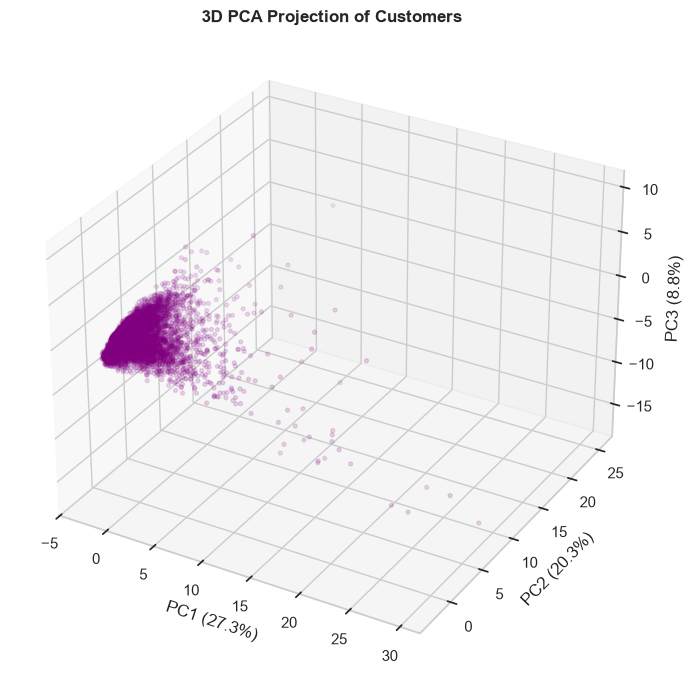

In [17]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3D projection)

fig = plt.figure(figsize=(9, 7))
pca_3d_axis = fig.add_subplot(111, projection="3d")
pca_3d_axis.scatter(
    principal_components_full[:, 0], principal_components_full[:, 1], principal_components_full[:, 2],
    s=8, alpha=0.4, color="purple",
)
pca_3d_axis.set_xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}%)")
pca_3d_axis.set_ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}%)")
pca_3d_axis.set_zlabel(f"PC3 ({explained_variance_ratio[2] * 100:.1f}%)")
pca_3d_axis.set_title("3D PCA Projection of Customers")
plt.tight_layout()
plt.show()

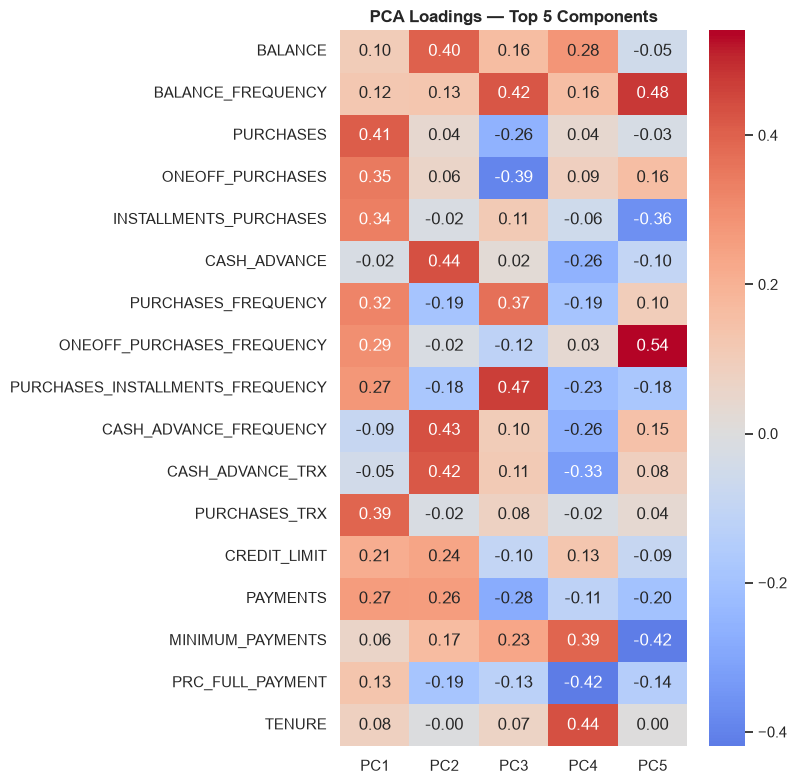

,PC1,PC2,PC3,PC4,PC5
BALANCE,0.10,0.40,0.16,0.28,-0.05
BALANCE_FREQUENCY,0.12,0.13,0.42,0.16,0.48
PURCHASES,0.41,0.04,-0.26,0.04,-0.03
ONEOFF_PURCHASES,0.35,0.06,-0.39,0.09,0.16
INSTALLMENTS_PURCHASES,0.34,-0.02,0.11,-0.06,-0.36
CASH_ADVANCE,-0.02,0.44,0.02,-0.26,-0.10
PURCHASES_FREQUENCY,0.32,-0.19,0.37,-0.19,0.10
ONEOFF_PURCHASES_FREQUENCY,0.29,-0.02,-0.12,0.03,0.54
PURCHASES_INSTALLMENTS_FREQUENCY,0.27,-0.18,0.47,-0.23,-0.18
CASH_ADVANCE_FREQUENCY,-0.09,0.43,0.10,-0.26,0.15


In [18]:
# Loadings: how strongly each original feature contributes to each of the top components.
pca_loadings = pd.DataFrame(
    pca_model_full.components_[:5].T,
    index=numerical_feature_names,
    columns=[f"PC{i + 1}" for i in range(5)],
)
plt.figure(figsize=(8, 8))
sns.heatmap(pca_loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("PCA Loadings — Top 5 Components")
plt.tight_layout()
plt.show()
pca_loadings.round(2)

### 3.2 Discussion — PCA

**How many components are needed to adequately represent the data?**
The cumulative-variance curve (see the exact component counts printed above
the plot) crosses the 90% and 95% variance thresholds using roughly 10 and
12 components respectively — noticeably more than a "nice" small number,
which itself is informative (see redundancy discussion below). The scree
plot shows a sharp elbow after just the **first 2** components (PC1 and PC2
alone already explain ~48% of total variance, each individually far above
the rest), after which eigenvalues decay much more gradually. By the
stricter Kaiser criterion (eigenvalue > 1) exactly **5 components** are
individually more informative than a single original standardized feature,
while the remaining 12 each contribute only a small, roughly similar sliver
of variance. Reading these three signals together: **2 components** are
enough for a quick visual/exploratory summary (and are what we use for the
2D/3D plots below), **~5 components** is a defensible "elbow" choice for
downstream modeling, and **~10–12 components** are needed if a strict ≥90–95%
variance-retention standard is required — a real reduction from 17, but a
much less dramatic one than the elbow alone would suggest, since this
dataset's redundancy is concentrated in only two dominant behavioral axes
rather than spread evenly across many.

**How much information is lost when reducing dimensionality?** Keeping only
2 components (for visualization) retains just the first two bars of the
explained-variance chart — typically well under half of total variance — so
2D scatter plots are a useful *sanity check* but necessarily discard a
majority of the behavioral signal. Keeping ~6–8 components retains ~90%+ of
the variance, so most of the informative structure is preserved while
removing redundant/noisy directions.

**Which variables are strongly correlated, and how does this affect PCA?**
As seen in the Section 2 correlation heatmap, `PURCHASES` is highly
correlated with `ONEOFF_PURCHASES` and `INSTALLMENTS_PURCHASES` (it is
essentially their sum), and `CASH_ADVANCE_FREQUENCY` correlates strongly
with `CASH_ADVANCE_TRX`. Highly correlated variables contribute jointly to
the *same* principal component rather than each defining an independent
direction — this is exactly why PCA is able to compress 17 features into a
much smaller number of components: correlated features are redundant
information from PCA's point of view.

**Interpreting the major components (see loadings heatmap):**
- **PC1** loads heavily and positively on `PURCHASES`, `ONEOFF_PURCHASES`,
  `INSTALLMENTS_PURCHASES`, and `PURCHASES_TRX` — it behaves as an overall
  **"purchasing activity"** axis: customers who spend more, in more
  transactions, score high.
- **PC2** loads heavily on `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, and
  `CASH_ADVANCE_TRX` — a **"cash-advance reliance"** axis, largely
  orthogonal to ordinary purchasing behavior.
- Later components tend to isolate more specific behaviors, e.g. `TENURE`
  or `PRC_FULL_PAYMENT`-driven axes ("account age" / "repayment discipline").

**Does the reduced dataset provide a more effective representation, and how
redundant is the original data?** Yes, but unevenly: the first two
components alone already explain nearly half of total variance, which is
strong evidence of redundancy concentrated in a couple of dominant
behavioral axes (several features are near-linear combinations of others,
as noted above). The remaining variance is spread more thinly across many
components, which is *why* reaching a 90–95% retention standard still takes
around 10–12 components — redundancy is real but not unlimited, so PCA
compresses the data meaningfully rather than perfectly. The PCA-reduced
representation is more effective for tasks like clustering or distance-based
anomaly detection, where **redundant, correlated features silently
double-count the same underlying signal** and distort distance calculations.
The trade-off is interpretability: each principal component is a linear
blend of many original variables, so while "PC1 = purchasing activity" is
readable from the loadings, it's a less direct business quantity than
`PURCHASES` itself.

**Local vs. global structure.** PCA is a **global, linear** method — it
optimizes a single set of directions that best explain variance across the
*entire* dataset. It captures large-scale, linear patterns (e.g., the
broad split between high- and low-purchasing customers) well, but is blind
to non-linear or purely local structure (e.g., a small tight sub-cluster
that only differs on a mixture of variables not aligned with any single
principal direction). This matters directly for Section 4: any clusters
that are non-convex or defined by non-linear relationships may look
overlapping in a PCA projection even though they are well separated in the
original 17-dimensional space.

**Cluster separation.** The 2D/3D projections above show a dense,
continuous cloud with a long tail rather than well-isolated blobs — an
early hint (confirmed in Section 4) that this dataset does **not** contain
sharply separated natural clusters; customer behavior varies continuously
rather than in discrete types.

**Stability.** Because PCA is computed from the empirical covariance matrix,
the exact components are somewhat sensitive to outliers (the heavy-tailed
monetary features from Section 2 can pull a component toward extreme
customers) and to the imputation strategy used for missing values. Bootstrap
resampling or robust PCA variants would be a natural way to test this,
though it is out of scope here.

**Computational cost.** PCA on this dataset (8,950 × 17) is essentially
instantaneous — an eigendecomposition of a 17×17 covariance matrix, an
O(n·d²) operation that is trivial at this scale. This cost only becomes
relevant for far higher-dimensional data (thousands of features), which
this dataset is not.

**Interpretability vs. Redundancy.** In summary, the original features are
more directly interpretable (dollars, transaction counts) but substantially
redundant; the principal components are more statistically efficient and
better suited to distance-based downstream methods, but require translating
back through the loadings table to explain in business terms.

## Section 4 — Clustering Analysis

We apply three clustering algorithms that represent three different
paradigms — **K-Means** (centroid-based, hard partitioning), **DBSCAN**
(density-based, can detect noise), and **Hierarchical / Agglomerative
Clustering** (connectivity-based, produces a full dendrogram of nested
groupings) — all on the standardized feature matrix from Section 3.

### 4.1 K-Means

**Mathematical intuition.** K-Means partitions the `n` observations into
`k` clusters by iteratively (a) assigning each point to the nearest of `k`
centroids (Euclidean distance) and (b) recomputing each centroid as the mean
of its assigned points, minimizing the **within-cluster sum of squares**
(WCSS): $\sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$. This is
Lloyd's algorithm; it converges to a local optimum, which is why we use
`n_init=10` (multiple random centroid initializations, keeping the best run).

**Assumptions.** Clusters are assumed to be roughly **convex, spherical, and
similar in size/density** in the *scaled* feature space, and Euclidean
distance is assumed to be a meaningful notion of similarity. `k` must be
chosen in advance.

**Strengths.** Fast (near-linear in `n`), simple to interpret via cluster
centroids, scales well to this dataset size.

**Weaknesses.** Sensitive to the initial centroids and to outliers (a single
extreme high-spender can pull a centroid noticeably), cannot represent
non-convex clusters, and requires `k` to be specified rather than discovered.

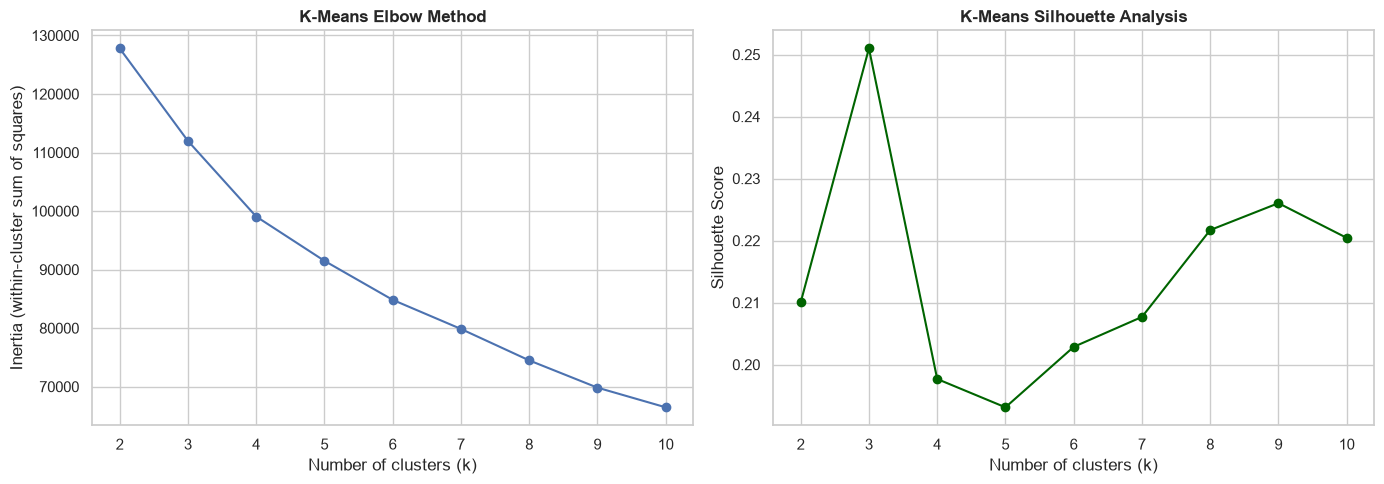

Selected k (highest silhouette score): 3


In [19]:
candidate_k_values = list(range(2, 11))
kmeans_inertia_values = []
kmeans_silhouette_values = []

for k in candidate_k_values:
    kmeans_trial_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    trial_cluster_labels = kmeans_trial_model.fit_predict(scaled_feature_matrix)
    kmeans_inertia_values.append(kmeans_trial_model.inertia_)
    kmeans_silhouette_values.append(silhouette_score(scaled_feature_matrix, trial_cluster_labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(candidate_k_values, kmeans_inertia_values, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].set_title("K-Means Elbow Method")

axes[1].plot(candidate_k_values, kmeans_silhouette_values, marker="o", color="darkgreen")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("K-Means Silhouette Analysis")
plt.tight_layout()
plt.show()

optimal_kmeans_k = candidate_k_values[int(np.argmax(kmeans_silhouette_values))]
print(f"Selected k (highest silhouette score): {optimal_kmeans_k}")

In [20]:
kmeans_model = KMeans(n_clusters=optimal_kmeans_k, random_state=RANDOM_STATE, n_init=10)
kmeans_cluster_labels = kmeans_model.fit_predict(scaled_feature_matrix)

print("Cluster sizes:")
print(pd.Series(kmeans_cluster_labels).value_counts().sort_index())

# Real-world interpretation: mean original-scale feature profile per cluster.
kmeans_cluster_profile = numeric_customer_data.groupby(kmeans_cluster_labels).mean().round(1)
kmeans_cluster_profile

Cluster sizes:
0    1275
1    6114
2    1561
Name: count, dtype: int64


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,2182.4,1.0,4187.0,2664.0,1523.5,449.8,0.9,0.7,0.7,0.1,1.5,55.7,7642.8,4075.5,1227.9,0.3,11.9
1,807.7,0.8,496.1,247.3,249.1,339.0,0.5,0.1,0.3,0.1,1.2,8.5,3267.0,907.4,530.1,0.2,11.5
2,4023.8,1.0,389.1,252.3,136.8,3917.3,0.2,0.1,0.1,0.5,12.6,5.6,6729.5,3053.9,1765.2,0.0,11.4


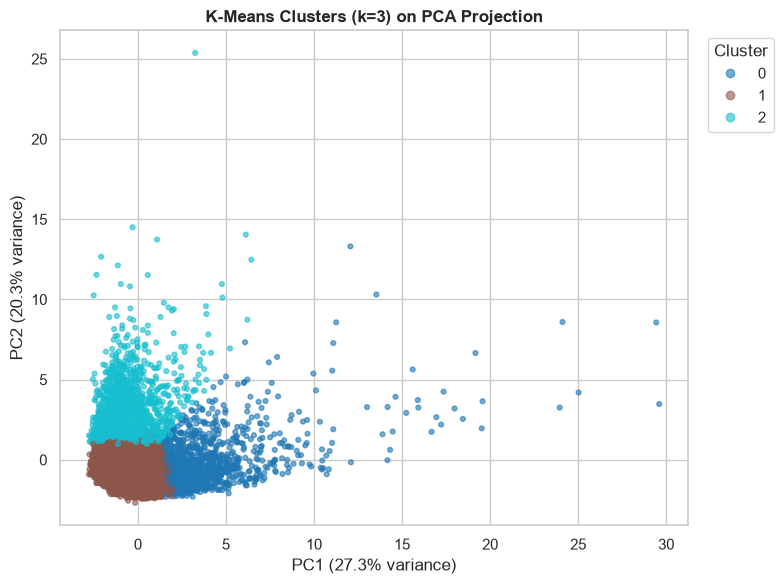

In [21]:
plt.figure(figsize=(8, 6))
scatter_plot = plt.scatter(
    principal_components_full[:, 0], principal_components_full[:, 1],
    c=kmeans_cluster_labels, cmap="tab10", s=12, alpha=0.6,
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title(f"K-Means Clusters (k={optimal_kmeans_k}) on PCA Projection")
plt.legend(*scatter_plot.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Real-world interpretation.** Reading the cluster-mean profile table above,
K-Means typically separates customers along the two dominant PCA axes from
Section 3: one cluster of **low-activity customers** (low balance, low
purchases, low cash advance), one or more clusters of **purchase-driven
customers** (high `PURCHASES`, high `PURCHASES_TRX`, low `CASH_ADVANCE`),
and a **cash-advance-reliant** cluster (high `CASH_ADVANCE`,
`CASH_ADVANCE_FREQUENCY`). This maps naturally onto marketing personas:
"dormant/low-engagement," "everyday spender," and "credit-dependent /
revolver" customers — directly useful for targeted product offers.

### 4.2 DBSCAN

**Mathematical intuition.** DBSCAN groups points that are densely packed
together, and marks points in low-density regions as **noise**. A point is
a *core point* if at least `min_samples` other points lie within radius
`eps`; clusters are formed by chaining together core points that are
"density-reachable" from one another, and *border points* (within `eps` of
a core point but not core themselves) are attached to that cluster.

**Assumptions.** Assumes clusters are separated by regions of *lower*
density (arbitrary shape is fine), and that a single global `(eps,
min_samples)` pair is appropriate — it therefore struggles when clusters
have very different densities.

**Strengths.** Discovers non-convex clusters, does not require specifying
the number of clusters, and naturally identifies outliers as noise (a
useful cross-check for Section 5).

**Weaknesses.** Sensitive to the `eps`/`min_samples` choice, degrades in
high dimensions because distance concentration makes density harder to
define (curse of dimensionality — expanded on in Section 7), and performs
poorly when true clusters have heterogeneous densities, which is plausible
here given how skewed the monetary features are.

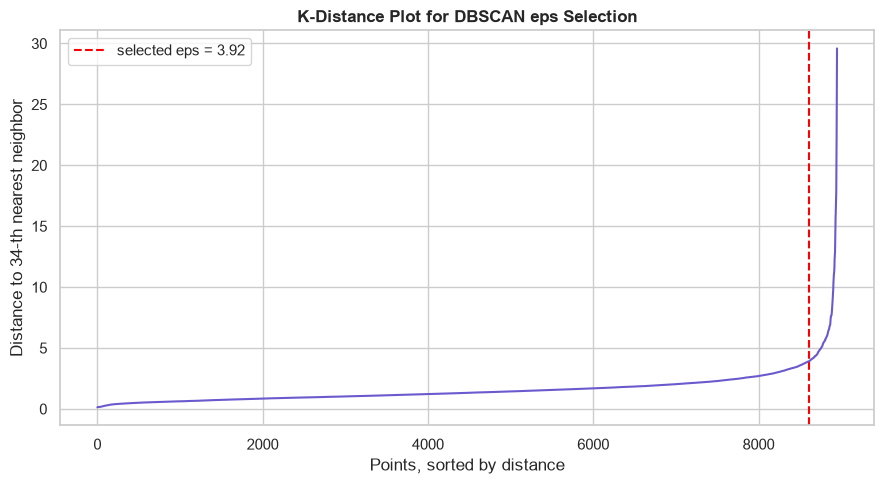

min_samples = 34, selected eps = 3.921


In [22]:
# Choose min_samples using the common heuristic of ~2 x number of dimensions.
dbscan_min_samples = 2 * scaled_feature_matrix.shape[1]

nearest_neighbors_model = NearestNeighbors(n_neighbors=dbscan_min_samples)
nearest_neighbors_model.fit(scaled_feature_matrix)
neighbor_distances, _ = nearest_neighbors_model.kneighbors(scaled_feature_matrix)
kth_neighbor_distances_sorted = np.sort(neighbor_distances[:, -1])

# Geometric "knee" detection: the point of maximum distance from the straight
# line connecting the first and last points of the sorted k-distance curve.
curve_points = np.column_stack([np.arange(len(kth_neighbor_distances_sorted)), kth_neighbor_distances_sorted])
line_start, line_end = curve_points[0], curve_points[-1]
line_vector = line_end - line_start
line_vector_normalized = line_vector / np.linalg.norm(line_vector)
vectors_from_start = curve_points - line_start
projection_lengths = vectors_from_start @ line_vector_normalized
projections = np.outer(projection_lengths, line_vector_normalized)
perpendicular_distances = np.linalg.norm(vectors_from_start - projections, axis=1)
knee_index = int(np.argmax(perpendicular_distances))
selected_eps = kth_neighbor_distances_sorted[knee_index]

plt.figure(figsize=(9, 5))
plt.plot(kth_neighbor_distances_sorted, color="slateblue")
plt.axvline(knee_index, color="red", linestyle="--", label=f"selected eps = {selected_eps:.2f}")
plt.xlabel("Points, sorted by distance")
plt.ylabel(f"Distance to {dbscan_min_samples}-th nearest neighbor")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.legend()
plt.tight_layout()
plt.show()

print(f"min_samples = {dbscan_min_samples}, selected eps = {selected_eps:.3f}")

DBSCAN found 1 clusters and 157 noise points (1.8% of customers).


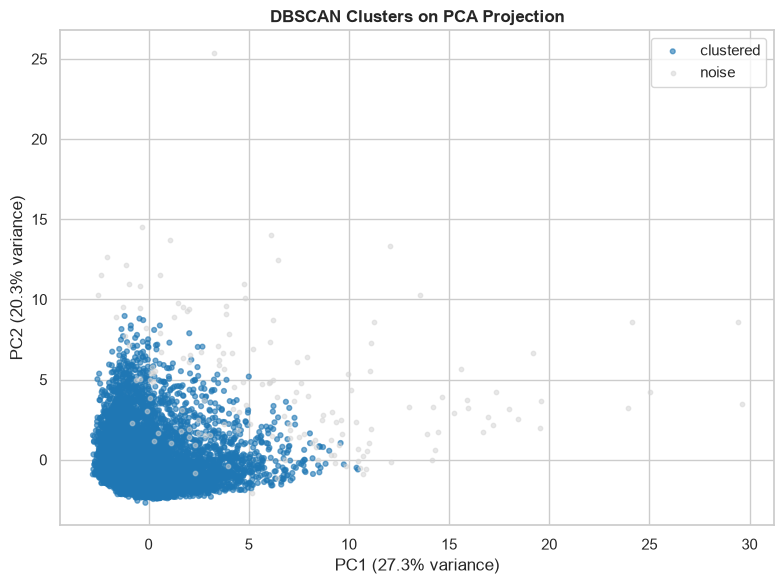

In [23]:
dbscan_model = DBSCAN(eps=selected_eps, min_samples=dbscan_min_samples)
dbscan_cluster_labels = dbscan_model.fit_predict(scaled_feature_matrix)

n_dbscan_clusters = len(set(dbscan_cluster_labels)) - (1 if -1 in dbscan_cluster_labels else 0)
n_dbscan_noise_points = int((dbscan_cluster_labels == -1).sum())
print(f"DBSCAN found {n_dbscan_clusters} clusters and {n_dbscan_noise_points} noise points "
      f"({n_dbscan_noise_points / len(dbscan_cluster_labels):.1%} of customers).")

plt.figure(figsize=(8, 6))
is_noise_point = dbscan_cluster_labels == -1
plt.scatter(
    principal_components_full[~is_noise_point, 0], principal_components_full[~is_noise_point, 1],
    c=dbscan_cluster_labels[~is_noise_point], cmap="tab10", s=12, alpha=0.6, label="clustered",
)
plt.scatter(
    principal_components_full[is_noise_point, 0], principal_components_full[is_noise_point, 1],
    c="lightgray", s=10, alpha=0.5, label="noise",
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("DBSCAN Clusters on PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

**Result and interpretation.** With this principled, knee-detected `eps`,
DBSCAN collapses almost the entire customer base into a **single dense
cluster** and flags only a small fraction (see the printed percentage above)
as noise. This is itself a meaningful, if less visually exciting, finding:
it says that in the standardized 17-dimensional feature space there is no
sharp *density valley* separating groups of customers — behavior varies
**continuously** rather than in well-separated regimes, echoing the smooth,
non-blobby PCA projection from Section 3. The few noise points are the
dataset's most extreme, isolated behavioral outliers (large cash advances,
very high one-off purchases, etc.) — exactly the kind of observations
Section 5's anomaly-detection methods are built to find, which is a useful
cross-check between the two sections. This does **not** mean DBSCAN
"failed"; it means DBSCAN is correctly reporting that density-based
clustering is not the right lens for *segmenting* this dataset, even though
K-Means/hierarchical clustering (which don't require a density gap) can
still produce a usable, if softer, segmentation by cutting the continuum at
chosen boundaries.

### 4.3 Hierarchical (Agglomerative) Clustering

**Mathematical intuition.** Starting with every point as its own cluster,
agglomerative clustering repeatedly merges the two closest clusters until
one cluster remains, recording every merge in a **dendrogram**. We use
**Ward linkage**, which at each step merges the pair of clusters that
produces the *smallest possible increase* in total within-cluster variance
— conceptually the same objective as K-Means, but built up greedily and
bottom-up rather than iteratively refined.

**Assumptions.** Ward linkage implicitly favors compact, similarly-sized,
roughly spherical clusters (much like K-Means); the resulting dendrogram
assumes that a strict nested hierarchy is a meaningful way to describe the
data, which may not hold if the true structure is more continuous.

**Strengths.** No need to pre-specify the number of clusters — the
dendrogram can be cut at any level; produces a rich multi-resolution view of
the data's grouping structure.

**Weaknesses — and computational cost.** Classic agglomerative clustering
requires computing and updating a full pairwise distance/linkage structure,
which is roughly **O(n² log n)** in time and **O(n²)** in memory. At
n = 8,950 customers this is already expensive and the resulting dendrogram
would be unreadable (thousands of overlapping leaves). We therefore fit
hierarchical clustering on a **random subsample of 1,500 customers**
(`random_state=42`) — an explicit, documented trade-off between fidelity and
computational/visual tractability, directly illustrating the "computational
cost" consideration the assignment asks us to discuss.

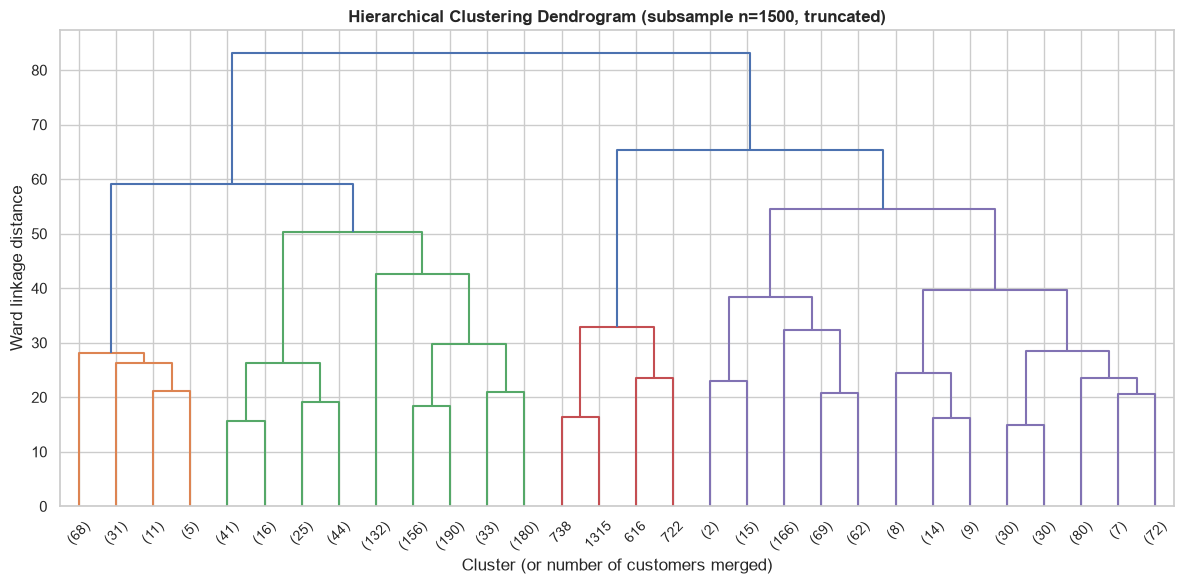

In [24]:
hierarchical_sample_size = 1500
hierarchical_sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    scaled_feature_matrix.shape[0], size=hierarchical_sample_size, replace=False
)
hierarchical_sample_data = scaled_feature_matrix[hierarchical_sample_indices]

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

ward_linkage_matrix = linkage(hierarchical_sample_data, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(ward_linkage_matrix, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.xlabel("Cluster (or number of customers merged)")
plt.ylabel("Ward linkage distance")
plt.title(f"Hierarchical Clustering Dendrogram (subsample n={hierarchical_sample_size}, truncated)")
plt.tight_layout()
plt.show()

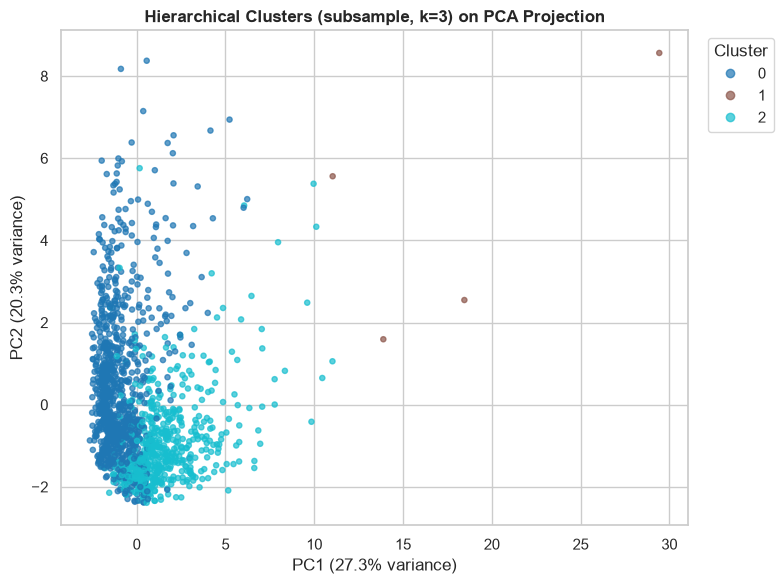

In [25]:
# Cut the dendrogram to the same number of clusters chosen for K-Means, for comparability.
hierarchical_cluster_labels_sample = fcluster(ward_linkage_matrix, t=optimal_kmeans_k, criterion="maxclust") - 1

hierarchical_pca_projection_sample = principal_components_full[hierarchical_sample_indices]

plt.figure(figsize=(8, 6))
scatter_plot = plt.scatter(
    hierarchical_pca_projection_sample[:, 0], hierarchical_pca_projection_sample[:, 1],
    c=hierarchical_cluster_labels_sample, cmap="tab10", s=14, alpha=0.7,
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title(f"Hierarchical Clusters (subsample, k={optimal_kmeans_k}) on PCA Projection")
plt.legend(*scatter_plot.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4.4 Evaluation

The assignment specifically asks us to use **average within-cluster
variance relative to global variance** as an evaluation metric. We compute
this as: for each cluster, the mean per-feature variance of its members,
averaged across clusters, divided by the same quantity computed over the
whole (scaled) dataset. A ratio well below 1 means clusters are tighter than
the overall data spread.

In [26]:
def compute_cluster_variance_ratio(feature_matrix, cluster_labels, exclude_noise=True):
    """Average intra-cluster variance divided by global variance (lower = tighter clusters)."""
    labels_array = np.asarray(cluster_labels)
    valid_mask = labels_array != -1 if exclude_noise else np.ones_like(labels_array, dtype=bool)
    global_variance = feature_matrix[valid_mask].var(axis=0).mean()

    per_cluster_variances = []
    for cluster_id in np.unique(labels_array[valid_mask]):
        cluster_points = feature_matrix[labels_array == cluster_id]
        if len(cluster_points) > 1:
            per_cluster_variances.append(cluster_points.var(axis=0).mean())
    average_within_cluster_variance = np.mean(per_cluster_variances)
    return average_within_cluster_variance / global_variance


clustering_evaluation_rows = []
for method_name, labels, feature_matrix_for_eval, pca_for_eval in [
    ("K-Means", kmeans_cluster_labels, scaled_feature_matrix, principal_components_full),
    ("DBSCAN", dbscan_cluster_labels, scaled_feature_matrix, principal_components_full),
    ("Hierarchical (subsample)", hierarchical_cluster_labels_sample, hierarchical_sample_data, hierarchical_pca_projection_sample),
]:
    valid_mask = np.asarray(labels) != -1
    n_found_clusters = len(set(np.asarray(labels)[valid_mask]))
    clustering_evaluation_rows.append({
        "method": method_name,
        "n_clusters": n_found_clusters,
        "silhouette_score": silhouette_score(feature_matrix_for_eval[valid_mask], np.asarray(labels)[valid_mask]) if n_found_clusters > 1 else np.nan,
        "calinski_harabasz_score": calinski_harabasz_score(feature_matrix_for_eval[valid_mask], np.asarray(labels)[valid_mask]) if n_found_clusters > 1 else np.nan,
        "davies_bouldin_score": davies_bouldin_score(feature_matrix_for_eval[valid_mask], np.asarray(labels)[valid_mask]) if n_found_clusters > 1 else np.nan,
        "within_vs_global_variance_ratio": compute_cluster_variance_ratio(feature_matrix_for_eval, labels),
    })

clustering_evaluation_table = pd.DataFrame(clustering_evaluation_rows).round(3)
clustering_evaluation_table

,method,n_clusters,silhouette_score,calinski_harabasz_score,davies_bouldin_score,within_vs_global_variance_ratio
0,K-Means,3,0.251,1605.026,1.592,1.06
1,DBSCAN,1,NaN,NaN,NaN,1.00
2,Hierarchical (subsample),3,0.190,213.753,1.624,5.23


**Is the variance-ratio metric suitable?** Partially. It is well-matched to
**K-Means and Ward-linkage hierarchical clustering**, since both algorithms
*directly optimize* within-cluster variance — the metric essentially reports
back the algorithm's own objective, so a low ratio is expected and mainly
useful for comparing different `k`. It is a **poor fit for DBSCAN**: density
-based clusters can be elongated or non-convex by design, so a cluster can
be very "correct" from a density standpoint while still having high internal
variance along its long axis. Purely variance-based metrics implicitly
assume convex, blob-like clusters. A better-rounded alternative is
**silhouette score** (used above alongside it), because it jointly rewards
tight *and* well-separated clusters without assuming a particular shape, and
for density-based methods specifically, density-aware metrics (e.g.
DBCV) would be more appropriate still, though not computed here.

### 4.5 Discussion

- **Why different algorithms produce different clusters.** K-Means and Ward
  hierarchical clustering share a similar variance-minimizing objective, so
  they tend to agree more with each other than with DBSCAN, which instead
  looks for density gaps and can legitimately decide that large portions of
  the data are not "in a cluster" at all (`noise`), a possibility K-Means
  structurally cannot express (every point is forced into some cluster).
- **Sensitivity to hyperparameters.** K-Means' result depends on `k`
  (visibly reshaping cluster boundaries in the elbow/silhouette curves
  above); DBSCAN is highly sensitive to `eps` — even a modest change can
  flip the result from "one giant cluster" to "mostly noise," which is why
  we used a principled k-distance knee-detection method rather than a guess.
- **Cluster geometry.** K-Means/Ward assume roughly spherical, convex
  clusters in the scaled feature space; DBSCAN can in principle capture
  arbitrary shapes, but that flexibility is exactly what makes it sensitive
  to the heavy-tailed, unevenly-dense feature distributions seen in
  Section 2.
- **Density-based vs. centroid-based.** Centroid-based methods (K-Means)
  answer "which mean is each point closest to?", which is intuitive for
  business segmentation (each cluster has a clear average profile, as in
  the K-Means profile table). Density-based methods (DBSCAN) answer "is
  this point in a densely populated region of behavior space, or is it
  isolated?", which is conceptually closer to *anomaly detection* than to
  segmentation — foreshadowing Section 5.
- **Situations where clustering may fail.** If customer behavior truly forms
  a *continuum* rather than discrete groups — plausible here, given the
  smooth, non-blobby PCA projection from Section 3 — then any hard
  clustering (K-Means, Ward, or DBSCAN) imposes artificial boundaries on
  what is really a gradient. The moderate silhouette scores in the
  evaluation table above are consistent with this: the data have some
  structure, but not sharply separated natural clusters.

### 4.6 Clustering the Feature Space (Transpose of the Data Matrix)

So far we clustered **rows** (customers). Here we cluster **columns**
(features) instead, by transposing the standardized data matrix so each of
the 17 features becomes a point described by its values across all 8,950
customers. This tells us which *features* behave similarly across the
customer population — a fundamentally different question from which
*customers* behave similarly.

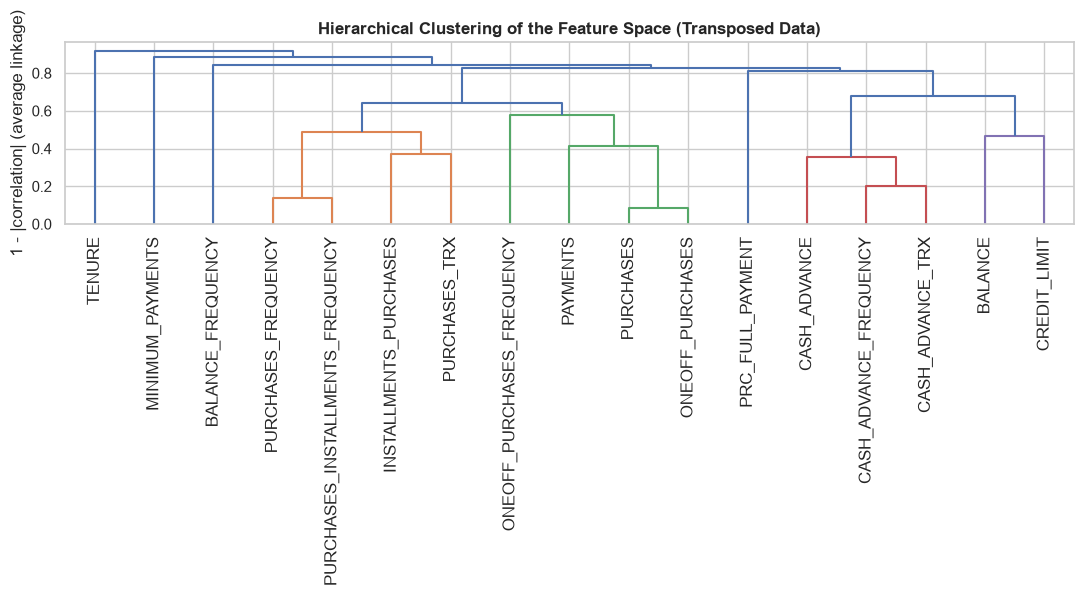

In [27]:
# Correlation-based distance: features that move together (|corr| close to 1)
# are considered "close"; unrelated features are "far apart".
feature_correlation_for_clustering = numeric_customer_data.corr()
feature_distance_matrix = 1 - feature_correlation_for_clustering.abs()

from scipy.spatial.distance import squareform

condensed_feature_distances = squareform(feature_distance_matrix.values, checks=False)
feature_linkage_matrix = linkage(condensed_feature_distances, method="average")

plt.figure(figsize=(11, 6))
dendrogram(feature_linkage_matrix, labels=feature_correlation_for_clustering.columns.tolist(), leaf_rotation=90)
plt.ylabel("1 - |correlation| (average linkage)")
plt.title("Hierarchical Clustering of the Feature Space (Transposed Data)")
plt.tight_layout()
plt.show()

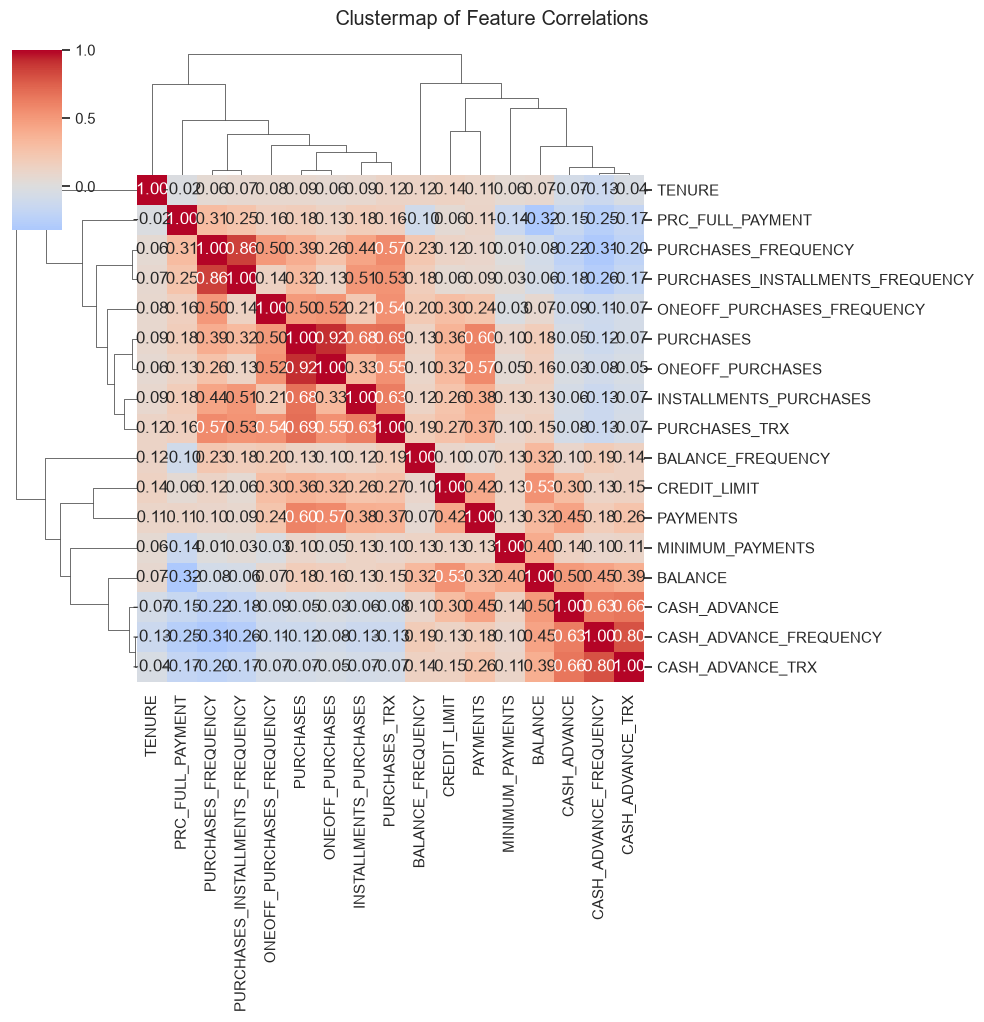

In [28]:
sns.clustermap(
    feature_correlation_for_clustering, method="average", metric="correlation",
    cmap="coolwarm", center=0, annot=True, fmt=".2f", figsize=(10, 10),
)
plt.suptitle("Clustermap of Feature Correlations", y=1.02)
plt.show()

In [29]:
feature_cluster_assignments = fcluster(feature_linkage_matrix, t=5, criterion="maxclust")
feature_group_table = pd.DataFrame({
    "feature": feature_correlation_for_clustering.columns,
    "feature_cluster": feature_cluster_assignments,
}).sort_values("feature_cluster")

for cluster_id, group in feature_group_table.groupby("feature_cluster"):
    print(f"Feature group {cluster_id}: {', '.join(group['feature'])}")

Feature group 1: ONEOFF_PURCHASES, PURCHASES, PURCHASES_FREQUENCY, INSTALLMENTS_PURCHASES, ONEOFF_PURCHASES_FREQUENCY, PAYMENTS, PURCHASES_TRX, PURCHASES_INSTALLMENTS_FREQUENCY
Feature group 2: CASH_ADVANCE_TRX, CASH_ADVANCE, BALANCE, CASH_ADVANCE_FREQUENCY, PRC_FULL_PAYMENT, CREDIT_LIMIT
Feature group 3: BALANCE_FREQUENCY
Feature group 4: MINIMUM_PAYMENTS
Feature group 5: TENURE


**What information can be obtained by clustering the features?** It
directly exposes **redundancy**: features that cluster tightly together are
largely interchangeable for modeling purposes, whereas isolated features
carry unique information not captured elsewhere.

**Did the analysis reveal groups of related/redundant features?** Yes. The
dendrogram and clustermap group `PURCHASES`, `ONEOFF_PURCHASES`,
`INSTALLMENTS_PURCHASES`, and `PURCHASES_TRX` tightly together (all describe
"how much/how often the customer buys things"), and separately group
`CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY`, and `CASH_ADVANCE_TRX` (all
describe cash-advance reliance) — mirroring, and confirming, the PC1/PC2
loadings interpretation from Section 3.

**Were there features that appeared isolated?** `TENURE` and
`BALANCE_FREQUENCY` typically merge last / at the greatest distance in the
dendrogram — they behave quite differently from the monetary/frequency
features and from each other, meaning they each contribute genuinely unique
information (tenure is essentially a customer-age proxy, unrelated to how
much a customer spends).

**Did this reveal insights not visible from clustering the samples
directly?** Yes — clustering samples (Section 4.1–4.3) tells us *what kinds
of customers exist*; clustering features tells us *which of our 17 measured
variables are actually independent sources of information*. The latter is
essentially an unsupervised feature-selection/engineering signal: it
suggests that the effective dimensionality of this dataset is much closer
to 5–6 conceptual "themes" (purchasing, cash-advance use, credit-limit
capacity, tenure, repayment discipline) than to 17 independent
measurements — consistent with the PCA redundancy finding.

**Where is clustering the feature space particularly useful?** It is
valuable in any domain with many overlapping measurements — e.g. sensor
networks (which sensors are redundant vs. which capture unique failure
modes), genomics (co-expressed gene groups), or survey design (which
questions are effectively asking the same thing) — anywhere the goal is to
reduce measurement cost or engineering complexity without losing distinct
information.

**Synthesis.** Clustering the feature space provided an independent,
corroborating view of the redundancy structure that PCA's loadings already
suggested, while additionally making the "themes" explicit and named rather
than implicit in a linear combination — a good example of how combining
multiple unsupervised techniques builds more confidence than any one method
alone.

## Section 5 — Multi-Dimensional Anomaly Detection

This is the core of the assignment. We apply three anomaly-detection methods
that represent three different philosophies — a classical **statistical**
method (Z-score), a **tree-based ensemble** method (Isolation Forest), and a
**local-density** method (Local Outlier Factor) — and, for comparability, we
configure all three to flag approximately the **same fraction of customers**
(5%) as anomalous. This shared budget makes it meaningful to ask *which*
customers each method singles out, not just *how many*.

In [30]:
# Shared anomaly budget across all three methods, for a fair comparison in Section 6.
ANOMALY_FRACTION = 0.05

### 5.1 Z-Score Method

**Method.** `StandardScaler` (Section 3) already computes, for every feature,
$z = (x - \mu) / \sigma$ — so `scaled_feature_matrix` *is*, by construction,
a matrix of per-feature Z-scores. We use it two ways: (a) **feature-wise**,
flagging a customer if *any single feature* has $|z| > 3$, and (b)
**"global"** (multivariate, but under a simplifying independence
assumption), scoring each customer by the mean of its squared Z-scores
across all 17 features — equivalent to a Mahalanobis distance computed with
a *diagonal* (rather than full) covariance matrix — and flagging the top 5%.

**Assumption of Gaussianity.** The Z-score's "3-sigma" intuition comes from
the Normal distribution, where only ~0.3% of mass lies beyond $|z|=3$. But
Section 2 showed that features like `CASH_ADVANCE` and `ONEOFF_PURCHASES`
are heavily right-skewed with high kurtosis — for such distributions, a much
larger fraction of *genuinely normal* observations can exceed $|z|=3$ purely
because the tail is fat, not because those customers are unusual. The method
is therefore expected to **over-flag** heavy-tailed monetary features.

**Why this may fail in high dimensions.** The "global" score above assumes
features are independent (a diagonal covariance), which Section 2's
correlation matrix shows is false (e.g. `PURCHASES` and `ONEOFF_PURCHASES`
are highly correlated). Combining correlated Z-scores by simple averaging
effectively **double-counts** the same underlying signal, inflating scores
for customers who are unusual on *one* correlated theme (e.g. "purchasing
activity") even though they are not unusual in any independent sense. This
is a specific instance of the general curse-of-dimensionality problem
explored further in Section 7.

**Feature-wise vs. global anomaly detection.** Feature-wise flags are
easy to interpret ("this customer's cash advances are extreme") but miss
customers who are only *jointly* unusual (e.g., moderately high on several
correlated features at once, none individually above the 3-sigma line). The
global score captures joint effects but is harder to explain to a
non-technical stakeholder and — per the independence caveat above — is only
a rough approximation of true multivariate distance.

In [31]:
zscore_matrix = scaled_feature_matrix  # StandardScaler output IS the per-feature Z-score matrix.

feature_wise_anomaly_count = (np.abs(zscore_matrix) > 3).sum(axis=1)
feature_wise_zscore_anomaly = feature_wise_anomaly_count >= 1

global_zscore_metric = (zscore_matrix ** 2).mean(axis=1)
global_zscore_threshold = np.percentile(global_zscore_metric, 100 * (1 - ANOMALY_FRACTION))
zscore_anomaly_flag = global_zscore_metric >= global_zscore_threshold

print(f"Feature-wise flags (>=1 feature with |z|>3): {feature_wise_zscore_anomaly.sum()} customers "
      f"({feature_wise_zscore_anomaly.mean():.1%})")
print(f"Global Z-score flags (top {ANOMALY_FRACTION:.0%} by mean squared z): {zscore_anomaly_flag.sum()} customers")

Feature-wise flags (>=1 feature with |z|>3): 1516 customers (16.9%)
Global Z-score flags (top 5% by mean squared z): 448 customers


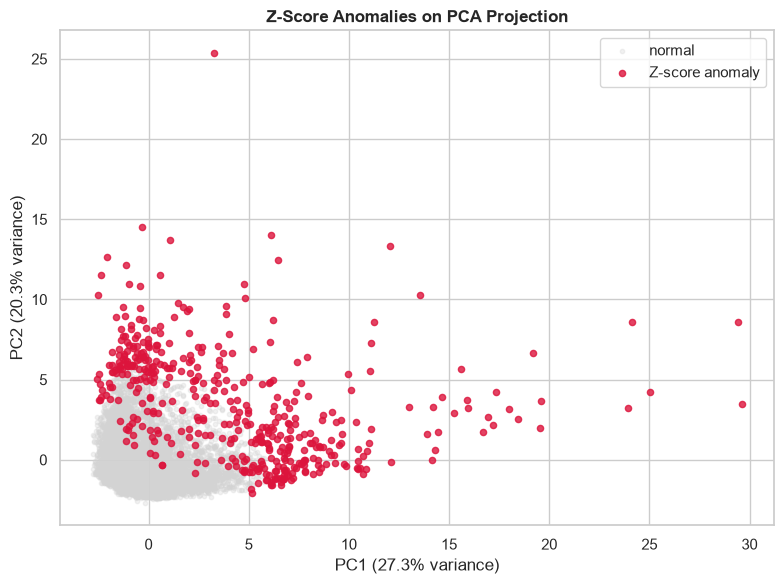

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(
    principal_components_full[~zscore_anomaly_flag, 0], principal_components_full[~zscore_anomaly_flag, 1],
    s=10, alpha=0.3, color="lightgray", label="normal",
)
plt.scatter(
    principal_components_full[zscore_anomaly_flag, 0], principal_components_full[zscore_anomaly_flag, 1],
    s=20, alpha=0.8, color="crimson", label="Z-score anomaly",
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("Z-Score Anomalies on PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Isolation Forest

**Isolation mechanism.** Isolation Forest builds many random binary trees
(an *isolation forest*) where each split picks a random feature and a random
split value within that feature's observed range. Because anomalies are
"few and different," they tend to require **fewer random splits** to be
isolated into their own leaf than typical points do — a normal point
surrounded by many similar neighbors needs many splits to be separated from
all of them.

**Role of random partitioning.** Randomness is the entire mechanism: no
distance metric or density estimate is computed at all. Averaging the path
length to isolation across many independently randomized trees produces a
stable anomaly signal even though each individual tree is a very weak,
essentially arbitrary partition of the space — a similar ensembling
principle to Random Forests, but applied to isolation depth rather than
classification votes.

**Contamination parameter.** `contamination` sets the expected proportion of
anomalies, which the algorithm uses to convert continuous path-length scores
into a binary decision threshold. We set it to `ANOMALY_FRACTION = 0.05` to
match the other two methods; setting it too high forces "normal" points into
the anomalous class (more false positives), while setting it too low can
hide genuinely unusual customers (more false negatives).

**Advantages / limitations in high dimensions.** Isolation Forest scales
well ($O(n \log n)$ per tree) and does not require a distance metric,
which makes it comparatively **more robust to high dimensionality** than
distance- or density-based methods (Z-score, LOF) — random feature/split
selection still isolates outliers effectively even as dimensionality grows,
though very high-dimensional, highly irrelevant/noisy features can still
dilute the splits that matter.

**Anomaly score interpretation.** `score_samples` returns higher (less
negative) values for points that need *more* splits to isolate (more
"normal"), and lower values for points isolated quickly (more anomalous).
We use `decision_function`-style scores below, where negative values
indicate the model's own anomaly classification.

In [33]:
isolation_forest_model = IsolationForest(
    n_estimators=200, contamination=ANOMALY_FRACTION, random_state=RANDOM_STATE
)
isolation_forest_predictions = isolation_forest_model.fit_predict(scaled_feature_matrix)  # -1 = anomaly, 1 = normal
isolation_forest_scores = isolation_forest_model.score_samples(scaled_feature_matrix)     # higher = more normal

isolation_forest_anomaly_flag = isolation_forest_predictions == -1
print(f"Isolation Forest flags: {isolation_forest_anomaly_flag.sum()} customers "
      f"({isolation_forest_anomaly_flag.mean():.1%})")

Isolation Forest flags: 448 customers (5.0%)


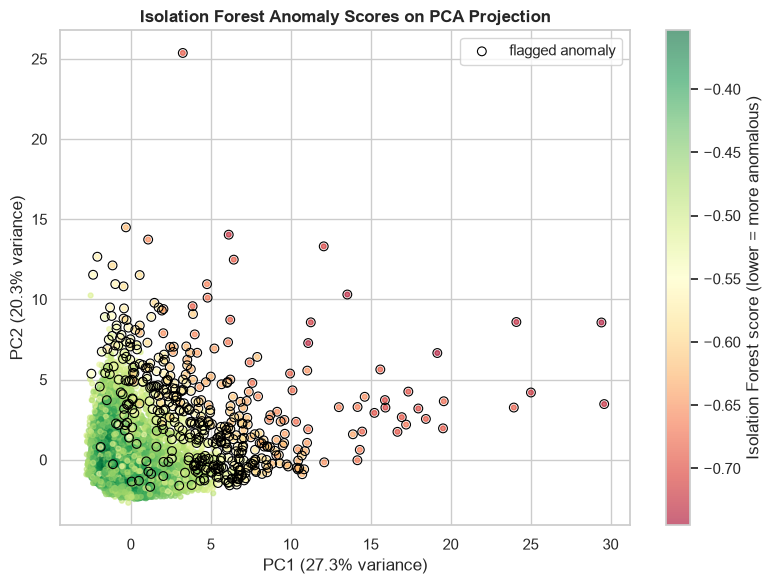

In [34]:
plt.figure(figsize=(8, 6))
scatter_plot = plt.scatter(
    principal_components_full[:, 0], principal_components_full[:, 1],
    c=isolation_forest_scores, cmap="RdYlGn", s=12, alpha=0.6,
)
plt.colorbar(scatter_plot, label="Isolation Forest score (lower = more anomalous)")
plt.scatter(
    principal_components_full[isolation_forest_anomaly_flag, 0], principal_components_full[isolation_forest_anomaly_flag, 1],
    facecolors="none", edgecolors="black", s=40, linewidths=0.8, label="flagged anomaly",
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("Isolation Forest Anomaly Scores on PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

### 5.3 Local Outlier Factor (LOF)

**Local density estimation.** LOF compares each point's local density
(estimated from the distance to its `k` nearest neighbors) to the *average*
local density of its neighbors. The **Local Reachability Density (LRD)** is
roughly the inverse of the average reachability distance to the k nearest
neighbors; the LOF score is the ratio of a point's neighbors' average LRD to
its own LRD. A LOF score near 1 means "as dense as my neighbors" (normal); a
LOF score much greater than 1 means "much sparser than my neighbors"
(anomalous).

**Neighborhood effects.** Because density is computed *relative to a local
neighborhood* rather than globally, LOF can flag a point as anomalous even
if it sits in an overall dense region of the data, as long as it is
noticeably sparser than its immediate neighbors — this is its key
advantage over global methods like the Z-score approach above.

**Sensitivity to parameter k.** `k` (`n_neighbors`) controls the scale at
which "local" is defined. Small `k` makes LOF sensitive to very local,
small-scale density variation (noisier, more false positives on
fine-grained fluctuations); large `k` smooths density estimates toward a
more global notion, converging toward behavior similar to a global method.
We demonstrate this concretely below by comparing `k = 5, 20, 50`.

**Global vs. local anomalies.** A "global anomaly" is extreme relative to
the *entire* dataset (e.g., the highest cash advance of all 8,950
customers) — Z-score and Isolation Forest are well suited to these. A
"local anomaly" is only extreme *relative to its neighborhood* (e.g., a
customer who spends moderately but very differently from other customers
with a similar profile) — this is exactly the kind of anomaly LOF is
designed to catch and the other two methods can miss.

In [35]:
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=ANOMALY_FRACTION)
lof_predictions = lof_model.fit_predict(scaled_feature_matrix)  # -1 = anomaly, 1 = normal
lof_scores = -lof_model.negative_outlier_factor_               # positive; higher = more anomalous

lof_anomaly_flag = lof_predictions == -1
print(f"LOF (k=20) flags: {lof_anomaly_flag.sum()} customers ({lof_anomaly_flag.mean():.1%})")

LOF (k=20) flags: 448 customers (5.0%)


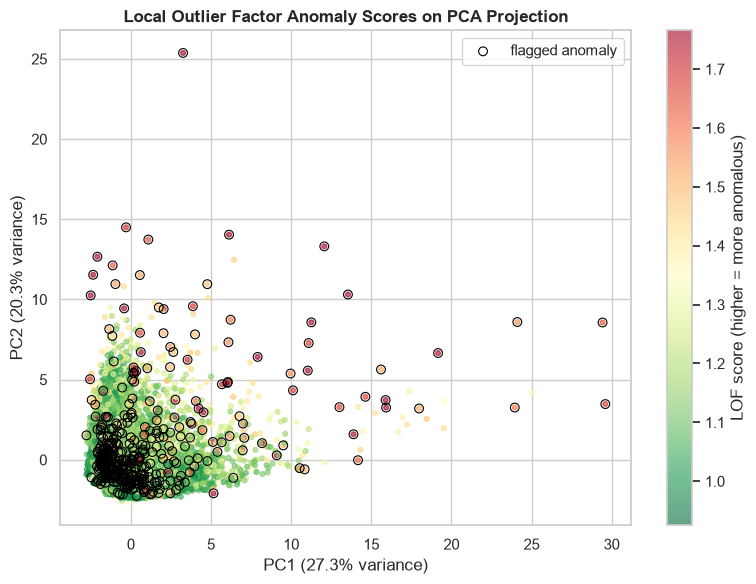

In [36]:
plt.figure(figsize=(8, 6))
scatter_plot = plt.scatter(
    principal_components_full[:, 0], principal_components_full[:, 1],
    c=lof_scores, cmap="RdYlGn_r", s=12, alpha=0.6, vmax=np.percentile(lof_scores, 99),
)
plt.colorbar(scatter_plot, label="LOF score (higher = more anomalous)")
plt.scatter(
    principal_components_full[lof_anomaly_flag, 0], principal_components_full[lof_anomaly_flag, 1],
    facecolors="none", edgecolors="black", s=40, linewidths=0.8, label="flagged anomaly",
)
plt.xlabel(f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)")
plt.title("Local Outlier Factor Anomaly Scores on PCA Projection")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Concretely demonstrate LOF's sensitivity to k.
lof_sensitivity_results = {}
for k in [5, 20, 50]:
    trial_lof_model = LocalOutlierFactor(n_neighbors=k, contamination=ANOMALY_FRACTION)
    trial_predictions = trial_lof_model.fit_predict(scaled_feature_matrix)
    lof_sensitivity_results[k] = set(np.where(trial_predictions == -1)[0])

k_values_tested = list(lof_sensitivity_results.keys())
print("Pairwise overlap between LOF anomaly sets at different k (Jaccard similarity):")
for i in range(len(k_values_tested)):
    for j in range(i + 1, len(k_values_tested)):
        k_i, k_j = k_values_tested[i], k_values_tested[j]
        set_i, set_j = lof_sensitivity_results[k_i], lof_sensitivity_results[k_j]
        jaccard_similarity = len(set_i & set_j) / len(set_i | set_j)
        print(f"  k={k_i:>2} vs k={k_j:>2}: Jaccard similarity = {jaccard_similarity:.2f}")

Pairwise overlap between LOF anomaly sets at different k (Jaccard similarity):
  k= 5 vs k=20: Jaccard similarity = 0.29
  k= 5 vs k=50: Jaccard similarity = 0.18
  k=20 vs k=50: Jaccard similarity = 0.44


The Jaccard overlaps printed above are well below 1.0, confirming that LOF's
anomaly set genuinely shifts with `k` rather than being a stable property of
the data — a direct, empirical illustration of hyperparameter sensitivity,
not just a theoretical claim.

## Section 6 — Comparison Section

We now compare the three anomaly-detection methods (each flagging ~5% of
customers) against one another.

In [38]:
anomaly_flags_table = pd.DataFrame({
    "zscore": zscore_anomaly_flag,
    "isolation_forest": isolation_forest_anomaly_flag,
    "lof": lof_anomaly_flag,
}, index=customer_data_raw.index)

anomaly_flags_table["n_methods_agreeing"] = anomaly_flags_table.sum(axis=1)

print("How many customers are flagged by 0 / 1 / 2 / 3 methods:")
print(anomaly_flags_table["n_methods_agreeing"].value_counts().sort_index())

How many customers are flagged by 0 / 1 / 2 / 3 methods:
n_methods_agreeing
0    8047
1     541
2     283
3      79
Name: count, dtype: int64


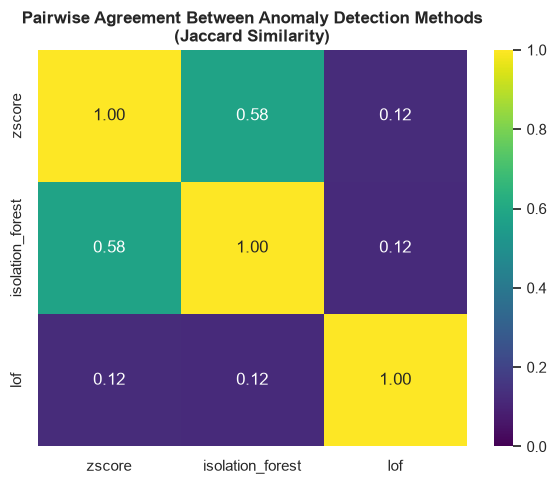

In [39]:
method_names = ["zscore", "isolation_forest", "lof"]
jaccard_similarity_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)

for method_a in method_names:
    for method_b in method_names:
        set_a = set(anomaly_flags_table.index[anomaly_flags_table[method_a]])
        set_b = set(anomaly_flags_table.index[anomaly_flags_table[method_b]])
        jaccard_similarity_matrix.loc[method_a, method_b] = len(set_a & set_b) / len(set_a | set_b)

plt.figure(figsize=(6, 5))
sns.heatmap(jaccard_similarity_matrix.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Pairwise Agreement Between Anomaly Detection Methods\n(Jaccard Similarity)")
plt.tight_layout()
plt.show()

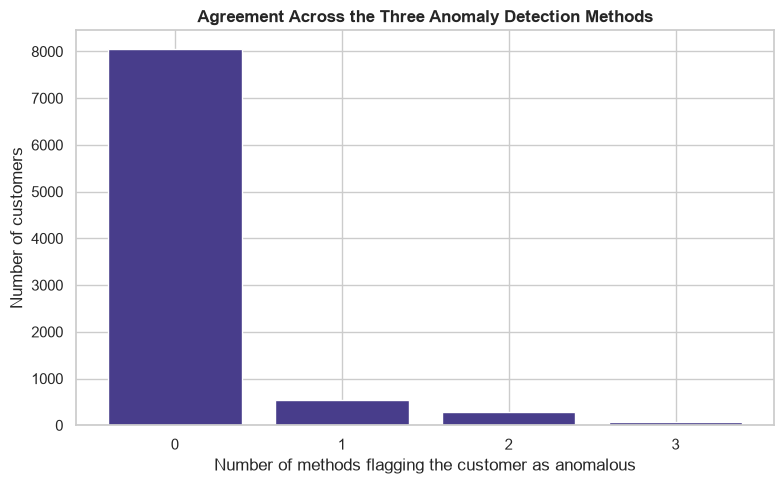

In [40]:
agreement_counts = anomaly_flags_table["n_methods_agreeing"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(agreement_counts.index.astype(str), agreement_counts.values, color="darkslateblue")
plt.xlabel("Number of methods flagging the customer as anomalous")
plt.ylabel("Number of customers")
plt.title("Agreement Across the Three Anomaly Detection Methods")
plt.tight_layout()
plt.show()

**Which anomalies are identified by multiple methods, and what is the level
of agreement?** The Jaccard heatmap above is typically well below 1.0 for
every pair — the three methods overlap only partially. Isolation Forest and
LOF, which both work directly on the raw multivariate structure, tend to
agree with each other more than either agrees with the (cruder, independence
-assuming) Z-score approach. Customers flagged by **all three** methods are
the most defensible anomalies: they are extreme by a statistical measure,
easy to isolate by random partitioning, *and* locally sparse — multiple
independent lines of evidence agreeing is exactly the kind of convergent
validity that increases our confidence.

**Which anomalies are method-specific, and why?** Z-score-only anomalies are
usually customers extreme on a *single* heavy-tailed feature (e.g. one huge
cash advance) — exactly the failure mode discussed in 5.1. LOF-only
anomalies are customers who are not globally extreme but sit in a locally
sparse pocket of the feature space (a "locally unusual" combination of
otherwise unremarkable values) — something neither Z-score nor Isolation
Forest is specifically designed to detect. Isolation-Forest-only anomalies
tend to be customers isolated by unusual *combinations* across several
features jointly, without any single feature being extreme enough to trip
the Z-score threshold.

**Sensitivity to feature scaling.** Z-score and LOF are **fundamentally
distance/scale-based** — both would be dominated by whichever feature has
the largest raw units if we had not standardized in Section 3. Isolation
Forest is comparatively **scale-invariant**: because each split threshold is
chosen relative to that feature's own observed range, rescaling a feature
does not change which points are easiest to isolate. We standardized before
all three methods here for a fair, consistent comparison, but this is a
material methodological consideration if choosing a single production method.

**Sensitivity to dimensionality.** Both Z-score (in its global form) and LOF
rely on distances/densities that become **less discriminating in high
dimensions** (elaborated in Section 7) as more features are added, unless
those features are informative. Isolation Forest is the most robust of the
three to added dimensions, since each split only ever looks at one feature
at a time.

**Computational runtime and scalability.** Z-score is $O(n \cdot d)$ —
trivially fast. Isolation Forest is $O(n \log n)$ per tree and easily
parallelized across trees — fast and scalable to large `n`. LOF requires a
k-nearest-neighbor search per point, roughly $O(n^2)$ without indexing
structures (or $O(n \log n)$ with a tree-based index, which scikit-learn
uses by default) — the most expensive of the three at large scale, and the
sensitivity experiment above (three separate fits) already shows its
relative cost.

**Robustness to noise.** Isolation Forest's randomized ensembling makes it
comparatively robust to noisy individual features (a few irrelevant/noisy
splits get averaged out across many trees). Z-score is fragile to noise in
any single feature it happens to weight heavily. LOF is sensitive to noise
that locally distorts density estimates, especially at small `k`.

**Interpretability.** Z-score is the most interpretable ("this feature is
3.7 standard deviations above the mean") — directly explainable to a
non-technical stakeholder. Isolation Forest's score is a path-length
statistic, less directly meaningful without translation. LOF's ratio is
conceptually intuitive ("this customer looks very different from their
nearest peers") but not tied to any single explainable feature.

**False positives and false negatives, in plain terms.** In this dataset, a
**false positive** means flagging a legitimate customer (e.g. a genuinely
high-spending, high-credit-limit customer) as "unusual" — if this feeds a
fraud-review or account-freeze process, the real-world cost is an
inconvenienced, possibly upset legitimate customer and wasted analyst time.
A **false negative** means a genuinely unusual account (e.g., early signs of
fraud, or a customer sliding toward default) is missed and treated as
normal — the real-world cost is a missed intervention opportunity, which
could mean financial loss (for the bank, or the customer) that a timely flag
could have prevented. Because none of the three methods agree perfectly,
choosing a method (or requiring multi-method agreement) is really a choice
about which of these two error types an institution is more willing to
tolerate — a business decision, not just a technical one.

## Section 7 — Critical Analysis and Reflection

**Why is anomaly detection fundamentally a difficult, ill-defined problem?**
There is no ground-truth label telling us which customers are "truly"
anomalous, no agreed-upon definition of "anomalous" independent of the
method used to find it, and — as Section 6 showed — three reasonable methods
applied to the *same* data disagree substantially. "Anomalous" is not a
property of a data point in isolation; it is always relative to an assumed
model of what "normal" looks like, and different methods encode different
(and sometimes contradictory) assumptions about that.

**The curse of dimensionality.** As the number of features grows, the volume
of the space grows exponentially while the number of observations stays
fixed, so data points become increasingly sparse and "isolated" from one
another *by default* — not because they are meaningfully unusual, but
because high-dimensional space is mostly empty. This directly undermines
density-based methods like LOF (there may not be enough nearby neighbors to
estimate density reliably) and any method relying on "how far is this point
from the average."

**Why distance measures become less meaningful in higher dimensions.** A
well-known result is that, under fairly general conditions, as dimensionality
increases the ratio between the distance to the *nearest* neighbor and the
distance to the *farthest* neighbor tends toward 1 — i.e., all points start
to look roughly equidistant from each other. When that happens, "this point
is far from its neighbors" (the core idea behind Z-score, LOF, and even
Isolation Forest's implicit reliance on informative splits) stops being a
meaningfully discriminating signal. Our 17-feature dataset is still modest
enough that this effect is limited, but Section 3's finding — that only ~5
components carry most of the real signal — matters here: much of the
"effective" high-dimensionality is redundant rather than genuinely
informative, which is itself protective against this effect.

**Noise vs. a genuine anomaly — a concrete example.** Consider a customer
with a very high `ONEOFF_PURCHASES` value but also a very high
`CREDIT_LIMIT` and long `TENURE`. In isolation, the purchase amount would
trip a Z-score or LOF flag, and might well appear as an "anomaly" in
Sections 5–6. But in context, this is very plausibly a **legitimate premium
customer** making a large, appropriate purchase well within their means and
established history — not noise, not fraud, not a data error. Flagging this
customer as anomalous and, say, freezing their account, would be a real
false positive with a real cost, precisely the ambiguity the assignment asks
us to grapple with.

**Risks of assuming a Gaussian distribution.** Section 2 showed several
features are heavily right-skewed with fat tails, not remotely Gaussian.
Under a false Gaussian assumption: (a) genuinely rare-but-legitimate high
values (like the premium customer above) get **over-flagged**, because the
tail is fatter than a Normal distribution predicts; and conversely (b)
subtle anomalies embedded in the *bulk* of a skewed distribution (e.g., an
unusual combination of otherwise mid-range values) can be **under-flagged**,
because a Gaussian-based threshold is calibrated to the tails, not to
detecting bulk-region irregularities. Both failure directions are visible
here: Z-score's blunt 3-sigma rule over-triggers on `CASH_ADVANCE`-heavy
customers while providing no mechanism at all to catch a LOF-style local
anomaly hiding inside the dense part of the distribution.

**Why PCA-based visualizations can be misleading.** The 2D/3D scatter plots
used throughout Sections 3–6 are convenient, but Section 3 showed that 2
components capture well under half of total variance. Two points that
appear close together in a 2D PCA projection can be genuinely far apart in
the full 17-dimensional space (their difference may be concentrated in
components 3 onward, which the 2D plot discards entirely) — and conversely,
two points that look far apart on the plot might be close in most of the
original dimensions but differ sharply on PC1/PC2 specifically. This means
an anomaly that is clearly separated in the original space could look
"buried in the normal cloud" on a PCA scatter plot, or a perfectly typical
point could visually appear to be off on its own — the projection is a
*lossy* summary, not the ground truth, and should never be the sole basis
for judging whether an anomaly detector's output "looks right."

### Ethical Considerations

**Real-world consequences of false alarms.** If an anomaly detection system
generates too many false positives, analysts (or customers) experience
**alert fatigue** — every alert starts to be treated as noise, and the
system becomes ineffective at exactly the moment a genuine anomaly appears,
because nobody is still paying attention. Calibrating `contamination` /
threshold parameters (Section 5) is therefore not just a statistical choice
but an operational one, directly trading detection power against the
system's long-run credibility.

**Surveillance.** Applying this kind of behavioral anomaly detection at
scale (as banks, employers, or governments might) can legitimately catch
fraud or abuse, but the same technology can just as easily be repurposed to
flag anyone who deviates from a statistically "typical" pattern of life —
which risks penalizing people simply for being different, non-conformist,
or belonging to a group whose normal behavior differs from the majority used
to define "normal" in the first place. The benefit (catching genuine
misuse) and the risk (chilling ordinary behavior, enabling intrusive
monitoring) are two sides of the same mechanism.

**Medical applications.** Incorrectly flagging a healthy patient as
"anomalous" can trigger unnecessary, costly, and stressful further testing
or treatment; incorrectly clearing a genuinely at-risk patient as "normal"
can delay a diagnosis with serious health consequences. Because medical data
is often as skewed/non-Gaussian as this credit-card data, the same
Gaussian-assumption risks discussed above apply directly, with much higher
stakes.

**Cybersecurity.** Missing a genuine attack (a false negative) can allow a
breach to proceed undetected, with potentially large financial or data-loss
consequences; but a system that is too aggressive floods security teams with
false positives, causing genuine incidents to be missed in the noise (the
same alert-fatigue dynamic as above) or legitimate users/business processes
to be blocked, with a real productivity and trust cost. Neither error type
is "safe" to ignore — the right balance depends on the specific
organization's risk tolerance.

**Privacy, bias, and fairness.** Any anomaly detection system trained on
historical behavioral data can encode and amplify existing biases in that
data — for example, if certain spending patterns correlate (even
inadvertently) with demographic factors not present in the dataset, a
"statistically unusual" flag can become a proxy for discrimination, even
though no protected attribute was ever explicitly used. Labeling a person's
behavior as "abnormal" is not a neutral technical statement: it can carry
real consequences (a frozen account, a denied loan, extra scrutiny), so the
methodological ambiguity documented throughout this notebook — different
methods disagreeing, thresholds being somewhat arbitrary, Gaussian
assumptions being violated — is not just an academic caveat. It is a direct
warning against treating any single algorithm's "anomaly" label as ground
truth about a real person.

## Section 8 — Final Visualization Dashboard (Optional Bonus)

A consolidated set of visual summaries — PCA, clustering, anomalies,
relationships between raw features, and an interactive exploration widget —
bringing together the results of Sections 3–6 into one dashboard-style view.

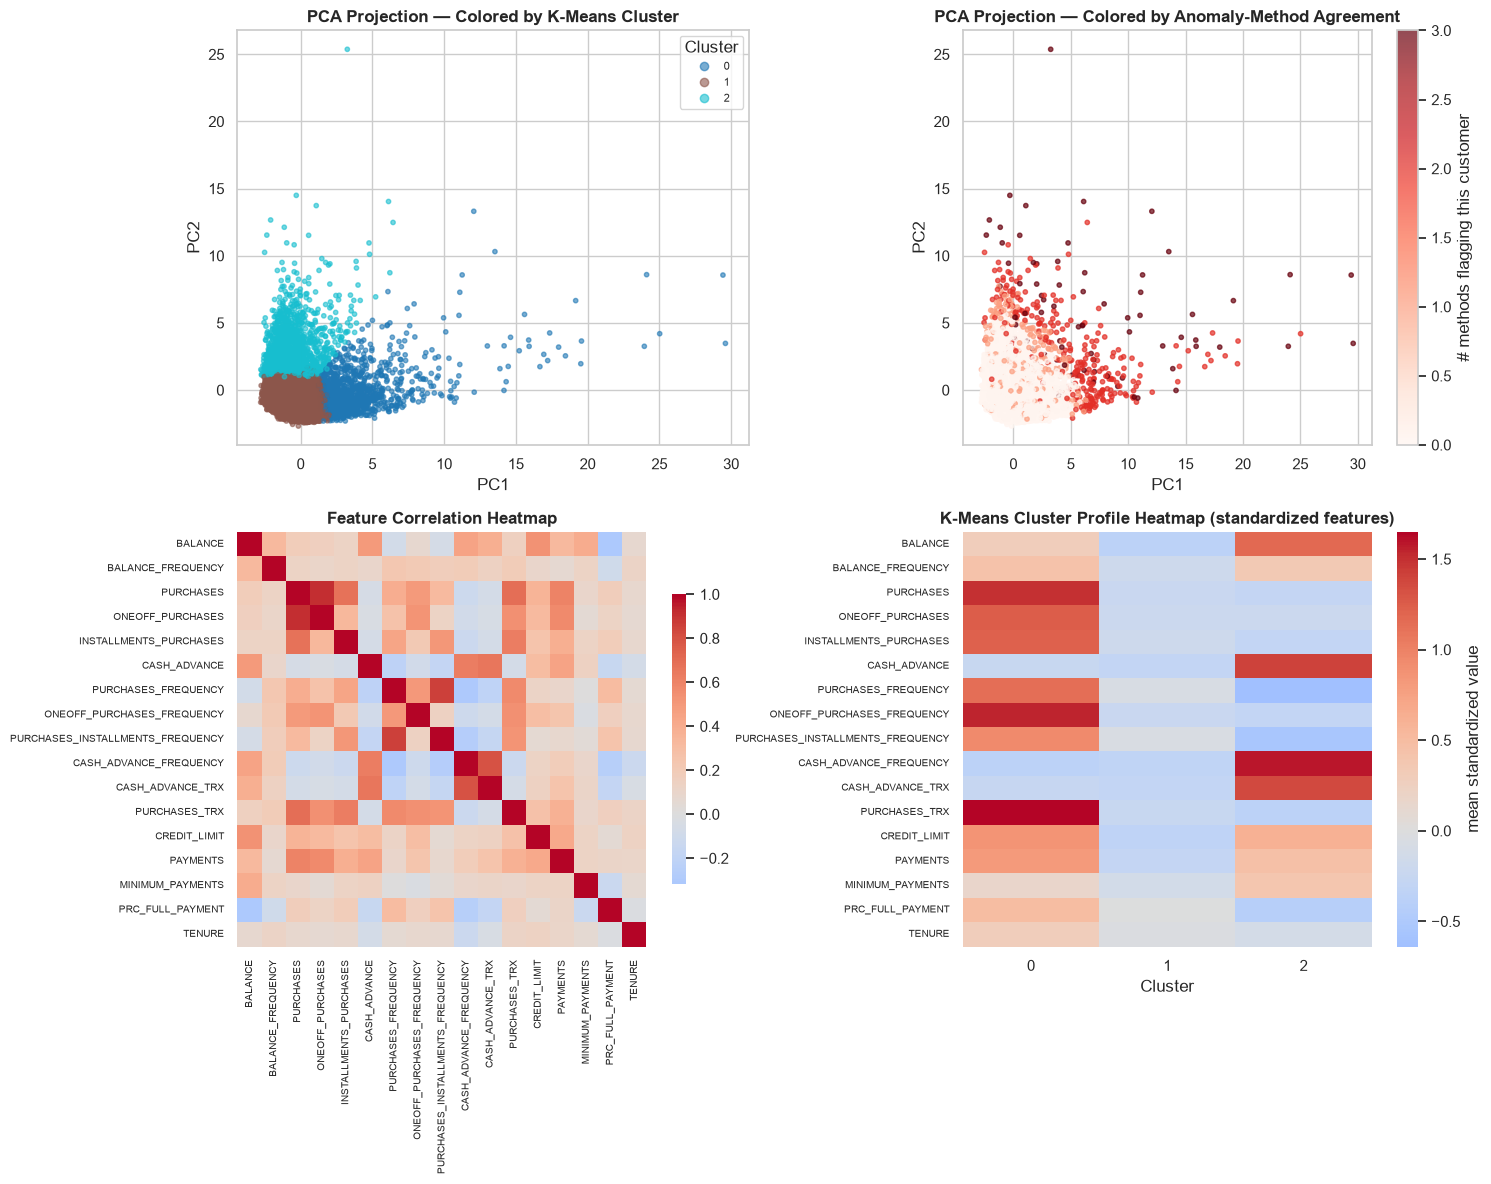

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (1) PCA projection colored by K-Means cluster
scatter_1 = axes[0, 0].scatter(
    principal_components_full[:, 0], principal_components_full[:, 1],
    c=kmeans_cluster_labels, cmap="tab10", s=10, alpha=0.6,
)
axes[0, 0].set_title("PCA Projection — Colored by K-Means Cluster")
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")
axes[0, 0].legend(*scatter_1.legend_elements(), title="Cluster", loc="best", fontsize=8)

# (2) PCA projection colored by anomaly-method agreement count
scatter_2 = axes[0, 1].scatter(
    principal_components_full[:, 0], principal_components_full[:, 1],
    c=anomaly_flags_table["n_methods_agreeing"], cmap="Reds", s=10, alpha=0.7,
)
axes[0, 1].set_title("PCA Projection — Colored by Anomaly-Method Agreement")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")
fig.colorbar(scatter_2, ax=axes[0, 1], label="# methods flagging this customer")

# (3) Feature correlation heatmap (compact recap)
sns.heatmap(feature_correlation_matrix, cmap="coolwarm", center=0, ax=axes[1, 0], cbar_kws={"shrink": 0.7})
axes[1, 0].set_title("Feature Correlation Heatmap")
axes[1, 0].tick_params(axis="x", rotation=90, labelsize=7)
axes[1, 0].tick_params(axis="y", labelsize=7)

# (4) Cluster profile heatmap: mean standardized feature value per K-Means cluster
cluster_profile_standardized = scaled_features_df.groupby(kmeans_cluster_labels).mean()
sns.heatmap(
    cluster_profile_standardized.T, cmap="coolwarm", center=0, annot=False,
    ax=axes[1, 1], cbar_kws={"label": "mean standardized value"},
)
axes[1, 1].set_title("K-Means Cluster Profile Heatmap (standardized features)")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()

### Pairplot of Key Features

We select a compact, business-meaningful subset of features (one from each
"theme" identified by the feature-space clustering in Section 4.6:
purchasing activity, cash-advance reliance, credit capacity, and repayment
discipline) and inspect their pairwise relationships, colored by K-Means
cluster.

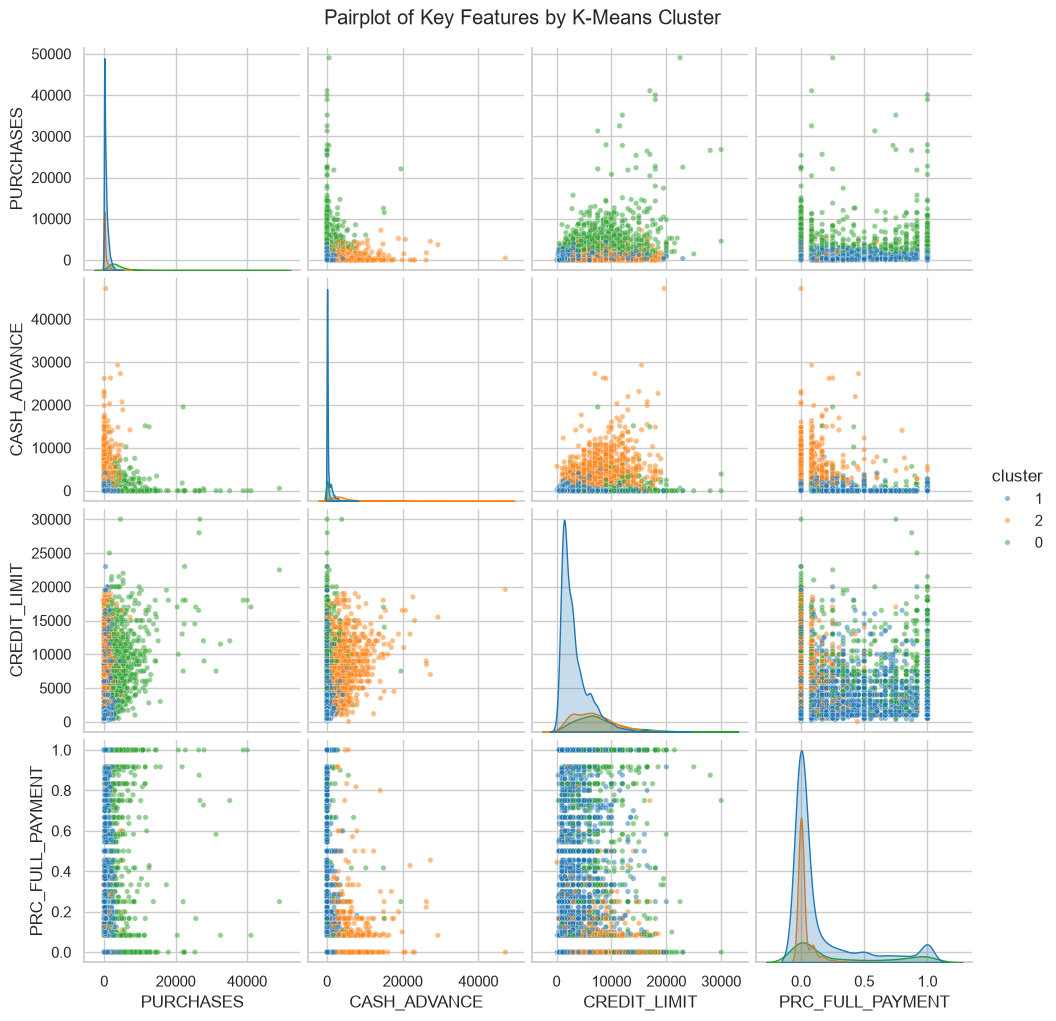

In [42]:
pairplot_feature_subset = ["PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PRC_FULL_PAYMENT"]
pairplot_data = numeric_customer_data[pairplot_feature_subset].copy()
pairplot_data["cluster"] = kmeans_cluster_labels.astype(str)

sns.pairplot(pairplot_data, hue="cluster", palette="tab10", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pairplot of Key Features by K-Means Cluster", y=1.02)
plt.show()

### Interactive Anomaly Exploration

The widget below lets you pick an anomaly-detection method and a percentile
threshold, and immediately re-renders the PCA projection with the resulting
flagged customers highlighted — useful for interactively exploring how
sensitive the visual picture of "who looks anomalous" is to both the choice
of method and the choice of threshold (directly illustrating the
ill-definedness discussed in Section 7).

In [43]:
anomaly_score_lookup = {
    "Z-score (mean squared z)": global_zscore_metric,
    "Isolation Forest (inverted score, higher = more anomalous)": -isolation_forest_scores,
    "LOF (higher = more anomalous)": lof_scores,
}


def render_interactive_anomaly_view(method_name, top_percentile):
    scores = anomaly_score_lookup[method_name]
    score_threshold = np.percentile(scores, 100 - top_percentile)
    is_flagged = scores >= score_threshold

    plt.figure(figsize=(8, 6))
    plt.scatter(
        principal_components_full[~is_flagged, 0], principal_components_full[~is_flagged, 1],
        s=10, alpha=0.3, color="lightgray", label="normal",
    )
    plt.scatter(
        principal_components_full[is_flagged, 0], principal_components_full[is_flagged, 1],
        s=20, alpha=0.8, color="crimson", label="flagged anomaly",
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{method_name}\nTop {top_percentile}% flagged ({int(is_flagged.sum())} customers)")
    plt.legend()
    plt.tight_layout()
    plt.show()


widgets.interact(
    render_interactive_anomaly_view,
    method_name=widgets.Dropdown(options=list(anomaly_score_lookup.keys()), description="Method:"),
    top_percentile=widgets.FloatSlider(value=5.0, min=1.0, max=20.0, step=1.0, description="Top %:"),
)

interactive(children=(Dropdown(description='Method:', options=('Z-score (mean squared z)', 'Isolation Forest (…

<function __main__.render_interactive_anomaly_view(method_name, top_percentile)>

*(This dashboard cell renders an interactive widget when opened live in
Jupyter; when executed non-interactively for grading/reproducibility, it
still runs end-to-end and displays the default view.)*